#Title: Big Data Analysis and Implementation for Enhancing Employee Well-being in organisations

##Table of Contents

Introduction


Design


*   Data Quality Improvement Strategies
*   Ontology Generation

Results and Discussion

Conclusion

References


##Introduction

**Brief Overview**

The project focuses on analyzing employee wellbeing using historical feedback data collected in a real organizational setting. Employee wellbeing is critical for fostering productivity, satisfaction, and retention within companies. The actual dataset, collected in 2019 and 2020, includes structured and unstructured feedback from employees, such as satisfaction ratings, workload metrics, and open-ended textual responses.


**Business Problem**

The objective is to identify the factors contributing to employee dissatisfaction and recommend actionable strategies to improve workplace wellbeing. By understanding key drivers and patterns in the data, businesses can make informed/ data based decisions to enhance employee wellbeing.




**Objective**

The primary goals of this analysis are:

1.   Feature Identification - analyze the dataset to determine the most important features impacting employee well-being.
2.  Visualization - use tools like Matplotlib and Seaborn to explore relationships within the data, uncover trends, and highlight key insights.
3. Insight Generation - extract actionable insights from both structured and unstructured data to address areas of dissatisfaction.
4. Strategic Recommendations - propose evidence-based recommendations for improving workplace wellbeing based on analysis results.

These four objectives aim to support organizations in enchasing employee wellbeing and fostering a healthier and more productive work environment.

##Metadology

###Data Selection

*   Structured Data Source:
  * Format: .csv
  * Origin:
      * Comercial data collected in Company through surveys and feedback mechanisms, gathered by the author, anonymized.
      
  * Attributes:
      * Employee ID (anonymized)
      * Department (anonymized)
      * Employee in department (numerical)
      * Year
      * Time spent in company (categorical)
      * 15 questions with answers (categorical)
          * 3 questions have answer hierarcy (categorical)
          * 1 question - Wellbeing Score (10 point Likert scale)
      * Volume: 980 KB.

      * Purpose: Provides structured tabular data, ideal for statistical analysis, aggregation, and visualization. This dataset enables comprehensive insights into employee demographics, well-being, and satisfaction.



*   Unstructured/Semi-Structured Data Source:

  *   Format: .json
  *   Origin: Comercial data collected in Company through surveys and feedback mechanisms, gathered by the author, anonymized.

  * Attributes:
      *   Employee ID (anonymized)
      *   Feedback Comments (unstructured text)

  * Volume: 246 KB.

  * Purpose: Facilitates hierarchical and relational analysis, particularly suited for Natural Language Processing (NLP) techniques and flexible querying. This data allows for deep insights into employee sentiment and textual feedback.

###Setup in Google Colab

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
!pip install rdflib
import dask.dataframe as dd
from cryptography.fernet import Fernet
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder  # Import OneHotEncoder for categorical features

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.1/565.1 kB 8.7 MB/s eta 0:00:00


###Data Loading and Exploration

* **Structured Data**

In [ ]:
# Loading structured data
structured_data = pd.read_csv('/content/structured_data.csv')

In [ ]:
# Data frame dimension
structured_data.shape

(54, 36)

In [ ]:
# Short view on data
structured_data.head()

,Respondent_ID,Nodaļa_Anonymized,Apmācības_vajadzības,Apmierinātība_ar_darba_laiku,Apmierinātība_ar_darba_slodzi,Apmierinātība_ar_informāciju,Dzimums,formid,Informācija_no_tiešā_vadītāja,Informācija_no_uzņēmuma_vadības,...,Stress_6,Stress_7,Tiešā_vadītāja_kompetence,Vēlamais_saziņas_veids_1,Vēlamais_saziņas_veids_2,Vēlamais_saziņas_veids_3,Vēlamais_saziņas_veids_4,Vēlamais_saziņas_veids_5,Vēlme_ieteikt_kompāniju,Vispārējās_labsajūtas_rādītājs
0,1,Nodaļa_1,Nē,Jā,Jā,Jā,Sieviete,form1027711226,Jā,Jā,...,NaN,NaN,Jā,"Telefoniski (sms, zvani)",Interneta vidē (e-pasts; sociālie tīkli vai pl...,Caur tiešo vadītāju,NaN,NaN,Ieteiktu,9
1,2,Nodaļa_3,"Jā, vēlos apgūt jaunas prasmes un pienākumus",Jā,Jā,Jā,Vīrietis,form1027711226,Jā,Jā,...,Nekas neizraisa,Nekas neizraisa,Jā,Caur tiešo vadītāju,Sapulces,"Telefoniski (sms, watsapp, zvani)",Interneta vidē (e-pasts; sociālie tīkli vai pl...,Informācija pie ziņojumu dēļiem (ja uzņēmumam ...,Ieteiktu,8
2,3,Nodaļa_1,"Jā, vēlos apgūt jaunas prasmes un pienākumus",Jā,Jā,"Cits: Ir brīži, kad trūkst nepieciešamā inform...",Sieviete,form1027711226,Jā,"Nē, jo informācija ir pārāk reti",...,NaN,NaN,Jā,Sapulces,Caur tiešo vadītāju,Interneta vidē (e-pasts; sociālie tīkli vai pl...,NaN,NaN,Ieteiktu,9
3,4,Nodaļa_7,"Jā, vēlos apgūt jaunas prasmes un pienākumus",Jā,Jā,Jā,Vīrietis,form1027711226,Jā,Jā,...,NaN,NaN,Jā,Interneta vidē (e-pasts; sociālie tīkli vai pl...,"Telefoniski (sms, Watsapp, zvani)",Caur tiešo vadītāju,NaN,NaN,Ieteiktu,9
4,5,Nodaļa_3,Cits,Cits,Cits,Cits,Vīrietis,form1027711226,Cits,"Nē, jo informācija ir pārāk reti",...,NaN,NaN,Cits,Cits,NaN,NaN,NaN,NaN,Ieteiktu,9


In [ ]:
# Check column data types and non-null values
print(structured_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Respondent_ID                    54 non-null     int64 
 1   Nodaļa_Anonymized                54 non-null     object
 2   Apmācības_vajadzības             54 non-null     object
 3   Apmierinātība_ar_darba_laiku     54 non-null     object
 4   Apmierinātība_ar_darba_slodzi    54 non-null     object
 5   Apmierinātība_ar_informāciju     54 non-null     object
 6   Dzimums                          54 non-null     object
 7   formid                           54 non-null     object
 8   Informācija_no_tiešā_vadītāja    54 non-null     object
 9   Informācija_no_uzņēmuma_vadības  54 non-null     object
 10  Izpratne_par_darba_pienākumiem   54 non-null     object
 11  Laiks_uzņēmumā                   54 non-null     object
 12  Novērtējums_1                    54 no

In [ ]:
# Summary statistics for all numeric columns
print(structured_data.describe())

       Respondent_ID  Vispārējās_labsajūtas_rādītājs
count      54.000000                       54.000000
mean       27.500000                        8.074074
std        15.732133                        1.163142
min         1.000000                        6.000000
25%        14.250000                        7.000000
50%        27.500000                        8.000000
75%        40.750000                        9.000000
max        54.000000                       10.000000


In [ ]:
# Summary statistics for specific columns
print(structured_data[['Company name','Department', 'Employee in department','Your time in the company?', 'Question', 'Answer']].describe())

KeyError: "None of [Index(['Company name', 'Department', 'Employee in department',\n       'Your time in the company?', 'Question', 'Answer'],\n      dtype='object')] are in the [columns]"

In [ ]:
# Analyze of data types (numerical, categorical, textual) and features like employee department, ratings, and feedback.

# 1. Understand the Dataset
print("Data Types and Feature Analysis:")

# Analyze data types
print("\nData Types:")
print(structured_data.dtypes)

# Analyze features
print("\nFeature Analysis:")

# Employee Department
print("\nEmployee Department:")
print(structured_data['Nodaļa_Anonymized'].value_counts()) # Frequency of each department
print(structured_data['Nodaļa_Anonymized'].unique())      # Unique departments


Data Types and Feature Analysis:

Data Types:
Respondent_ID                       int64
Nodaļa_Anonymized                  object
Apmācības_vajadzības               object
Apmierinātība_ar_darba_laiku       object
Apmierinātība_ar_darba_slodzi      object
Apmierinātība_ar_informāciju       object
Dzimums                            object
formid                             object
Informācija_no_tiešā_vadītāja      object
Informācija_no_uzņēmuma_vadības    object
Izpratne_par_darba_pienākumiem     object
Laiks_uzņēmumā                     object
Novērtējums_1                      object
Novērtējums_2                      object
Novērtējums_3                      object
Novērtējums_4                      object
Novērtējums_5                      object
Novērtējums_6                      object
Novērtējums_7                      object
Priekšlikumi_tiešajam_vadītājam    object
sent                               object
Stress_1                           object
Stress_2                      

*   **Unstructured/Semi-structured Data**

In [ ]:
# Loading unstructured data
unstructured_data = pd.read_json('/content/unstructured_data.json')

In [ ]:
# Display the first few rows
print(unstructured_data.head())

   Respondent_ID                     Apmācības_vajadzības_Komentāri  \
0              1                                               None   
1              2                                               None   
2              3                                               None   
3              4                                               None   
4              5  Vēlētos apgūt darba optimizāciju, un izprast v...   

                              Darba_slodze_komentārs  \
0                                               None   
1                                               None   
2                                               None   
3                                               None   
4  Vairāk ne, jo vajag iet ārpus sava darba apjom...   

                              Darba_laiks__komentāri  \
0                                               None   
1                                               None   
2                                               None   
3           

In [ ]:
# Check for null values
print(unstructured_data.isnull().sum())

Respondent_ID                                 0
Apmācības_vajadzības_Komentāri               50
Darba_slodze_komentārs                       44
Darba_laiks__komentāri                       49
Ieteikumi                                    20
Informācija_no_tiešā_vadītāja_Komentāri      49
Informācija_no_uzņēmuma_vadības_Komentāri    49
Izpratne_par_darba_pienākumiem_Komentāri     48
Nepieciešamā_informācija_Komentāri           47
Novērtējums_Komentāri                        50
Priekšlikumi_tiešajam_vadītājam_Komentāri    51
Saziņa_Komentāri                             49
Stress_Komentāri                             46
Tiešā_vadītāja_kompetence_Komentāri          49
Vēlme_darīt                                   0
Vēlme_ieteikt_kompāniju_Komentāri            48
Vispārējās_labsajūtas_rādītājs_Komentāri     50
dtype: int64


In [ ]:
# Summary statistics for numerical columns
print(unstructured_data.describe())

       Respondent_ID
count      54.000000
mean       27.500000
std        15.732133
min         1.000000
25%        14.250000
50%        27.500000
75%        40.750000
max        54.000000


In [ ]:
# Summary statistics for categorical columns
print(unstructured_data.describe(include=["object"]))

                           Apmācības_vajadzības_Komentāri  \
count                                                   4   
unique                                                  4   
top     Vēlētos apgūt darba optimizāciju, un izprast v...   
freq                                                    1   

                                   Darba_slodze_komentārs  \
count                                                  10   
unique                                                 10   
top     Vairāk ne, jo vajag iet ārpus sava darba apjom...   
freq                                                    1   

                                   Darba_laiks__komentāri Ieteikumi  \
count                                                   5        34   
unique                                                  5        34   
top     Un ja un ne, dažreiz var aiziet mājas laikus, ...      Nav.   
freq                                                    1         1   

       Informācija_no_tiešā_vadī

###Data Quality Improvement

1. Handling Missing Values

As author discovered before in this data set there is no missing values.

2. Data Type Correction






In [ ]:
# Converting data type from Object to Categorical
# Identify columns with 'object' dtype
object_columns = structured_data.select_dtypes(include=['object']).columns

# Loop through the columns and convert them to categorical
for col in object_columns:
  structured_data[col] = pd.Categorical(structured_data[col])

# Now check the data types again:
structured_data.dtypes

,0
Respondent_ID,int64
Nodaļa_Anonymized,category
Apmācības_vajadzības,category
Apmierinātība_ar_darba_laiku,category
Apmierinātība_ar_darba_slodzi,category
Apmierinātība_ar_informāciju,category
Dzimums,category
formid,category
Informācija_no_tiešā_vadītāja,category
Informācija_no_uzņēmuma_vadības,category


Outlier Detection and Treatment

Identify outliers in numerical data using box plots, scatter plots or statistical methods like IQR (Interquartile Range)

In [ ]:
# Outlier Detection and Treatment
# Use box plots or IQR to detect outliers and decide on treatment (removal or capping)
#Example using IQR for numerical column 'wellbeing_scores' (adjust column names)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
structured_data = remove_outliers_iqr(structured_data, 'Vispārējās_labsajūtas_rādītājs')

5. Text Cleaning (for unstructured data)

In [ ]:
#Text Cleaning (unstructured data)
# Verify the exact column names in unstructured_data by uncommenting the line below
# print(unstructured_data.columns)

# Update the list below with the correct column names from your unstructured_data DataFrame
text_columns_to_clean = [
    'Apmācības_vajadzības_Komentāri',
    'Darba_slodze_komentārs',
    'Darba_laiks__komentāri',
    'Ieteikumi',
    'Informācija_no_tiešā_vadītāja_Komentāri',
    'Informācija_no_uzņēmuma_vadības_Komentāri',
    'Izpratne_par_darba_pienākumiem_Komentāri',
    'Nepieciešamā_informācija_Komentāri',
    'Novērtējums_Komentāri',
    'Priekšlikumi_tiešajam_vadītājam_Komentāri',
    'Saziņa_Komentāri',
    'Stress_Komentāri',
    'Tiešā_vadītāja_kompetence_Komentāri',
    'Vēlme_darīt',
    'Vēlme_ieteikt_kompāniju_Komentāri',
    'Vispārējās_labsajūtas_rādītājs_Komentāri'
]

# Apply the lowercasing and stripping to the correct columns
unstructured_data[text_columns_to_clean] = unstructured_data[text_columns_to_clean].apply(lambda x: x.str.lower().str.strip())

7. Data Validation

In [ ]:
# Validate data against known constraints (e.g., valid ranges for numerical values, acceptable categories).
# Flag or correct invalid values.

# Data Validation
def validate_data(df):
    """
    Validates data in the DataFrame against known constraints.
    Flags or corrects invalid values.
    """

    # Example 1: Validating 'Vispārējās_labsajūtas_rādītājs' range
    valid_wellbeing_range = (1, 10)  # Assuming a valid range of 1-10

    invalid_wellbeing = df[~df['Vispārējās_labsajūtas_rādītājs'].between(*valid_wellbeing_range)]

    if not invalid_wellbeing.empty:
      print("Invalid wellbeing scores found:")
      print(invalid_wellbeing[['Vispārējās_labsajūtas_rādītājs']])

      # Options for handling:
      # 1. Remove invalid rows
      # df = df[df['Vispārējās_labsajūtas_rādītājs'].between(*valid_wellbeing_range)]

      # 2. Replace invalid with NaN or a default value (e.g. median)
      median_wellbeing = df['Vispārējās_labsajūtas_rādītājs'].median()
      df.loc[~df['Vispārējās_labsajūtas_rādītājs'].between(*valid_wellbeing_range), 'Vispārējās_labsajūtas_rādītājs'] = median_wellbeing

      # 3. Cap the values (set to minimum or maximum)
      # df.loc[df['wellbeing_scores'] < valid_wellbeing_range[0], 'wellbeing_scores'] = valid_wellbeing_range[0]
      # df.loc[df['wellbeing_scores'] > valid_wellbeing_range[1], 'wellbeing_scores'] = valid_wellbeing_range[1]

        # Example 2: Validating 'Department' categories
    valid_departments = ['Nodaļa_1', 'Nodaļa_2', 'Nodaļa_3', 'Nodaļa_4', 'Nodaļa_5', 'Nodaļa_6', 'Nodaļa_7','Izvēlos nenorādīt']
    invalid_departments = df[~df['Nodaļa_Anonymized'].isin(valid_departments)]

    if not invalid_departments.empty:
      print("Invalid departments found:")
      print(invalid_departments['Nodaļa_Anonymized'].unique())

      # Check if 'Other' is already a category before adding it
      if 'Other' not in df['Nodaļa_Anonymized'].cat.categories:
          df['Nodaļa_Anonymized'] = df['Nodaļa_Anonymized'].cat.add_categories(['Other'])

      # Now you can safely assign 'Other'
      df.loc[~df['Nodaļa_Anonymized'].isin(valid_departments), 'Nodaļa_Anonymized'] = 'Other'


    return df

structured_data = validate_data(structured_data)

 9. Consistency across datasets (Structured and Unstructured):
- Ensure that employee IDs and other identifying information match across both datasets if you plan to merge or join the data.
- Employ appropriate techniques to align and consolidate relevant data points from both structured and unstructured sources.

In [ ]:
# Consistency across datasets (Structured and Unstructured):
# 'Respondent ID' is the common identifier
# Merge the datasets based on 'Respondent ID'
merged_data = pd.merge(structured_data, unstructured_data, on='Respondent_ID', how='left')

# Check for inconsistencies in employee IDs
if not merged_data.empty:
    id_mismatches = merged_data[merged_data['Respondent_ID'].isnull()]
    if not id_mismatches.empty:
        print("Inconsistencies found in Respondent IDs:")
        print(id_mismatches)
    else:
        print("No inconsistencies found in Respondent IDs.")
else:
    print("No data found in the merged dataset")

No inconsistencies found in Respondent IDs.


10. Check for inconsistencies in data:
- Standardize formats (also important in date/time data if have).

In [ ]:
# Inconsistent Categories
# Standardize categorical values (e.g., lowercase, remove whitespace)
for col in structured_data.select_dtypes(include='object'):
    structured_data[col] = structured_data[col].str.lower().str.strip()  # convert to lowercase and remove whitespace

11. Deduplication:
- Remove duplicate rows from both datasets, if any.

In [ ]:
#Remove duplicate rows from both datasets, if any.

# Remove duplicate rows from structured data
structured_data.drop_duplicates(inplace=True)

# Remove duplicate rows from unstructured data
unstructured_data.drop_duplicates(inplace=True)

12. Normalizing of data

In [ ]:
# Question: How in general you would assess your well-being in the company with answers

# 'Vispārējās_labsajūtas_rādītājs' is the column you want to analyze (replace if different)
wellbeing_data = structured_data['Vispārējās_labsajūtas_rādītājs']

# Check if wellbeing_data is empty
if wellbeing_data.empty:
    print("No data found for the specified wellbeing question. Check the question text.")
else:
    # The data is already in the Series, no need to access it by column name again
    wellbeing_answers = wellbeing_data

    # Display the unique answers and their counts
    print(wellbeing_answers.value_counts())

Vispārējās_labsajūtas_rādītājs
9     18
7     14
8     12
6      5
10     5
Name: count, dtype: int64


In [ ]:
# wellbeing_data = structured_data['Vispārējās_labsajūtas_rādītājs'] # This line is now redundant here

# Check if wellbeing_data is empty
if wellbeing_data.empty:
    print("No data found for the specified wellbeing question. Check the question text.")
else:
    # Now you can access the corresponding answers, which are likely the wellbeing scores
    # The wellbeing_data Series already contains the scores, so no need to index again
    wellbeing_scores = wellbeing_data

    # Convert 'wellbeing_scores' to numeric, handling errors
    wellbeing_scores = pd.to_numeric(wellbeing_scores, errors='coerce')

    # Remove or replace non-numeric values (e.g., 'No answer')
    # Option 1: Remove rows with non-numeric values
    wellbeing_scores = wellbeing_scores.dropna()

    # Option 2: Replace non-numeric values with a specific value (e.g., 0)
    # wellbeing_scores = wellbeing_scores.fillna(0)

# 'Wellbeing Score' is the column we want to normalize
from sklearn.preprocessing import MinMaxScaler

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Reshape the data before scaling (MinMaxScaler expects a 2D array)
wellbeing_scores_reshaped = wellbeing_scores.values.reshape(-1, 1)

# Fit and transform the data
normalized_wellbeing_scores = scaler.fit_transform(wellbeing_scores_reshaped)

# Convert back to a pandas Series if needed
normalized_wellbeing_scores = pd.Series(normalized_wellbeing_scores.flatten(), name='Normalized Wellbeing Score')

# Now we can use normalized_wellbeing_scores in your analysis
print(normalized_wellbeing_scores.describe())

count    54.000000
mean      0.518519
std       0.290786
min       0.000000
25%       0.250000
50%       0.500000
75%       0.750000
max       1.000000
Name: Normalized Wellbeing Score, dtype: float64


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Identify all categorical columns based on the provided list
all_categorical_columns = [
    'Apmācības_vajadzības',
    'Apmierinātība_ar_darba_laiku',
    'Apmierinātība_ar_darba_slodzi',
    'Apmierinātība_ar_informāciju',
    'Dzimums',
    'formid',
    'Informācija_no_tiešā_vadītāja',
    'Informācija_no_uzņēmuma_vadības',
    'Izpratne_par_darba_pienākumiem',
    'Laiks_uzņēmumā',
    'Novērtējums_1',
    'Novērtējums_2',
    'Novērtējums_3',
    'Novērtējums_4',
    'Novērtējums_5',
    'Novērtējums_6',
    'Novērtējums_7',
    'Priekšlikumi_tiešajam_vadītājam',
    'sent',
    'Stress_1',
    'Stress_2',
    'Stress_3',
    'Stress_4',
    'Stress_5',
    'Stress_6',
    'Stress_7',
    'Tiešā_vadītāja_kompetence',
    'Vēlamais_saziņas_veids_1',
    'Vēlamais_saziņas_veids_2',
    'Vēlamais_saziņas_veids_3',
    'Vēlamais_saziņas_veids_4',
    'Vēlamais_saziņas_veids_5',
    'Vēlme_ieteikt_kompāniju',
    # 'Nodaļa_Anonymized' is included in the list initially but will be excluded later
    'Nodaļa_Anonymized'
]

# Ensure the columns actually exist in the DataFrame and exclude 'Nodaļa_Anonymized'
columns_to_encode = [col for col in all_categorical_columns if col in structured_data.columns and col != 'Nodaļa_Anonymized']

# Apply One-Hot Encoding to the selected columns
# Use handle_unknown='ignore' to handle potential categories not seen during fit
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_categorical_features = one_hot_encoder.fit_transform(structured_data[columns_to_encode])

# Create a DataFrame from the encoded features
encoded_feature_names = one_hot_encoder.get_feature_names_out(columns_to_encode)
encoded_structured_data_partial = pd.DataFrame(encoded_categorical_features, columns=encoded_feature_names, index=structured_data.index)

# Concatenate the one-hot encoded features with the original DataFrame
# This time, we drop only the columns that were encoded and keep 'Nodaļa_Anonymized'
structured_data_encoded_excluded = pd.concat([structured_data.drop(columns=columns_to_encode), encoded_structured_data_partial], axis=1)

print("Original structured data shape:", structured_data.shape)
print("Encoded structured data shape (excluding 'Nodaļa_Anonymized'):", structured_data_encoded_excluded.shape)
print("First few rows of the encoded data (excluding 'Nodaļa_Anonymized'):")
print(structured_data_encoded_excluded.head())

# Verify that 'Nodaļa_Anonymized' is still in the DataFrame
if 'Nodaļa_Anonymized' in structured_data_encoded_excluded.columns:
    print("\n'Nodaļa_Anonymized' column is still present in the encoded DataFrame.")
else:
    print("\n'Nodaļa_Anonymized' column was unexpectedly excluded.")

# Verify the data type of 'Nodaļa_Anonymized'
print("\nData type of 'Nodaļa_Anonymized':", structured_data_encoded_excluded['Nodaļa_Anonymized'].dtype)

Original structured data shape: (54, 36)
Encoded structured data shape (excluding 'Nodaļa_Anonymized'): (54, 226)
First few rows of the encoded data (excluding 'Nodaļa_Anonymized'):
   Respondent_ID Nodaļa_Anonymized  Vispārējās_labsajūtas_rādītājs  \
0              1          Nodaļa_1                               9   
1              2          Nodaļa_3                               8   
2              3          Nodaļa_1                               9   
3              4          Nodaļa_7                               9   
4              5          Nodaļa_3                               9   

   Apmācības_vajadzības_Cits  \
0                        0.0   
1                        0.0   
2                        0.0   
3                        0.0   
4                        1.0   

   Apmācības_vajadzības_Cits: Varētu ik pa laikam ka'dus kursus apmeklēt  \
0                                                0.0                       
1                                                0.0

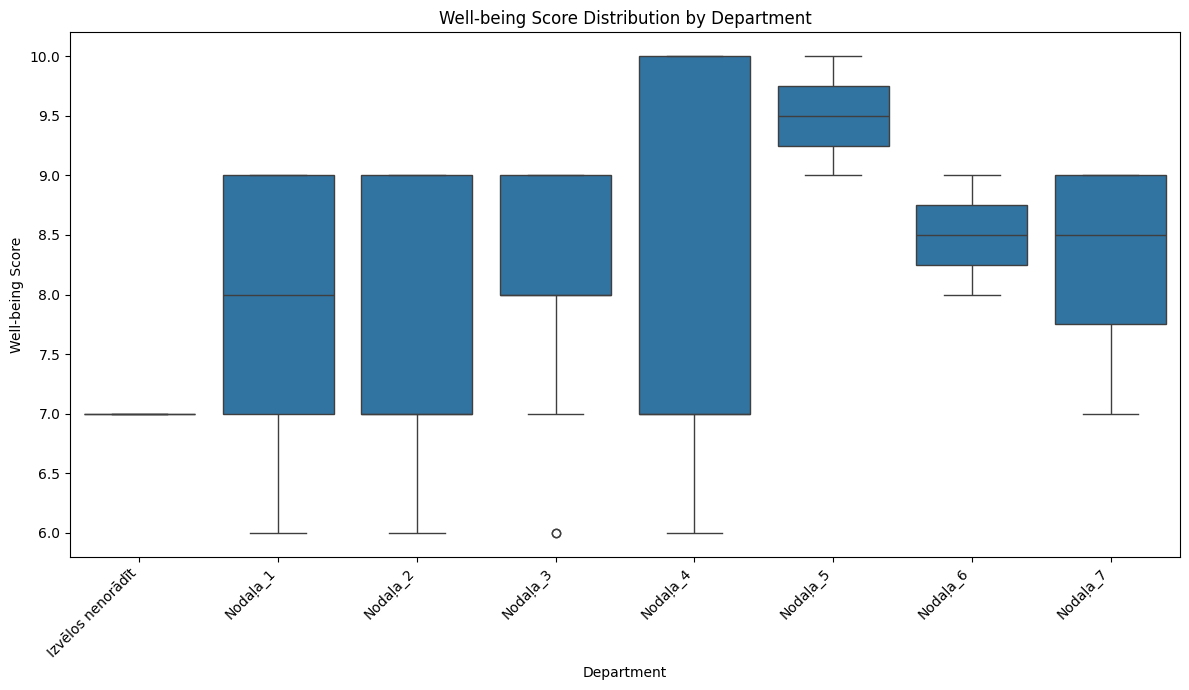

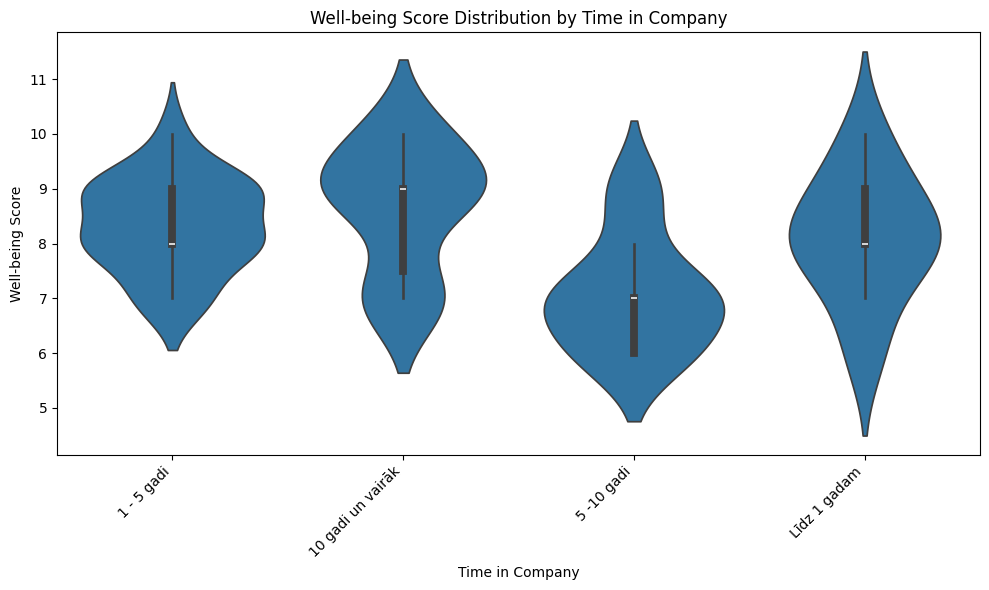

In [ ]:
# Assuming 'Vispārējās_labsajūtas_rādītājs' is your well-being score column
# And assuming 'Nodaļa_Anonymized' is an original categorical column of interest

if 'Vispārējās_labsajūtas_rādītājs' in structured_data.columns and 'Nodaļa_Anonymized' in structured_data.columns:
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Nodaļa_Anonymized', y='Vispārējās_labsajūtas_rādītājs', data=structured_data)
    plt.title('Well-being Score Distribution by Department')
    plt.xlabel('Department')
    plt.ylabel('Well-being Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Well-being score or Department columns not found in the original data.")

# You can repeat this for other original categorical columns in your dataset
# For example, 'Laiks_uzņēmumā' (Time in Company)
if 'Vispārējās_labsajūtas_rādītājs' in structured_data.columns and 'Laiks_uzņēmumā' in structured_data.columns:
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Laiks_uzņēmumā', y='Vispārējās_labsajūtas_rādītājs', data=structured_data)
    plt.title('Well-being Score Distribution by Time in Company')
    plt.xlabel('Time in Company')
    plt.ylabel('Well-being Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Well-being score or Time in Company columns not found in the original data.")

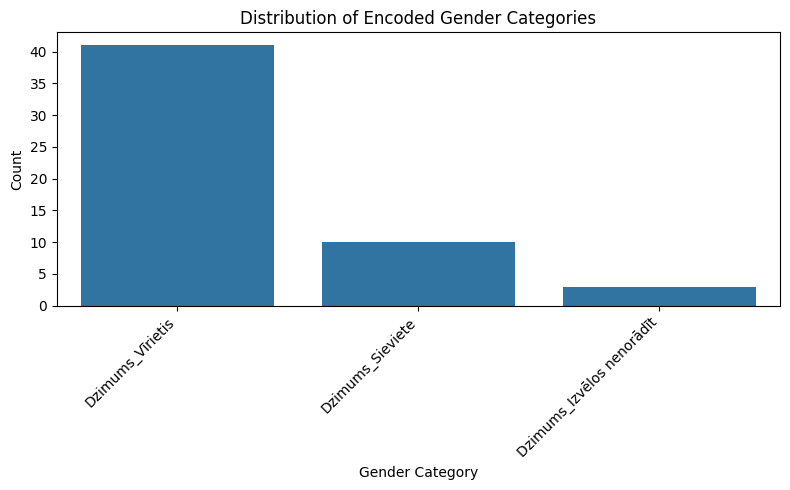

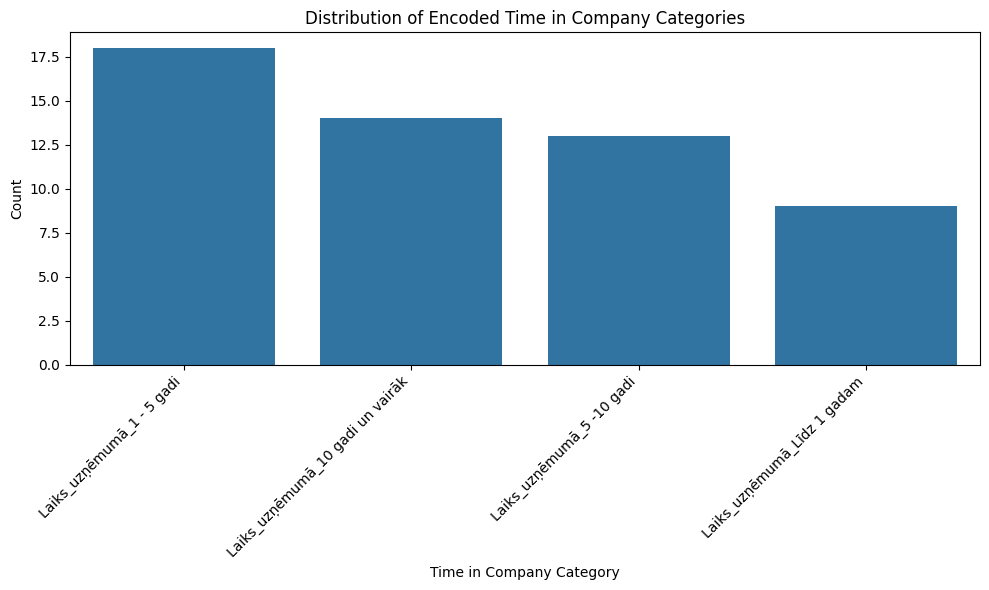

In [ ]:
# Get the names of the newly created one-hot encoded columns
# Replace existing_categorical_columns with columns_to_encode or the full list used for encoding
# Based on the last code block, the full list used for encoding is `columns_to_encode_present`
# FIX: Use 'columns_to_encode' as it was defined and used for fitting the encoder
encoded_feature_names = one_hot_encoder.get_feature_names_out(columns_to_encode) # Use the actual list of columns encoded

# You can visualize the counts for a few selected encoded features as an example
# Let's pick a few to demonstrate.
# You'll need to know the prefixes generated by OneHotEncoder for your columns.
# For example, if 'Nodaļa_Anonymized' was encoded, you might have columns like 'Nodaļa_Anonymized_Nodaļa_1', 'Nodaļa_Anonymized_Nodaļa_2', etc.
# Let's assume 'Dzimums' (Gender) was encoded and has categories like 'Male', 'Female'.
# The encoded columns might be 'Dzimums_Male', 'Dzimums_Female'.

# Example 1: Visualizing the distribution of encoded 'Dzimums' (Gender)
# Find the encoded columns related to 'Dzimums'
gender_encoded_cols = [col for col in encoded_feature_names if col.startswith('Dzimums')]

if gender_encoded_cols:
    # Sum the values in these columns to get the counts for each category
    # Use the correctly named DataFrame `structured_data_processed`
    # FIX: Use structured_data_encoded_excluded as it's the result of the previous encoding step
    gender_counts = structured_data_encoded_excluded[gender_encoded_cols].sum().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=gender_counts.index, y=gender_counts.values)
    plt.title('Distribution of Encoded Gender Categories')
    plt.xlabel('Gender Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels if they overlap
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()
else:
    print("Encoded gender columns not found. Check the original column name and encoding prefixes.")


# Example 2: Visualizing the distribution of encoded 'Laiks_uzņēmumā' (Time in Company)
# Find the encoded columns related to 'Laiks_uzņēmumā'
time_encoded_cols = [col for col in encoded_feature_names if col.startswith('Laiks_uzņēmumā_')]

if time_encoded_cols:
    # Use the correctly named DataFrame `structured_data_processed`
    # FIX: Use structured_data_encoded_excluded as it's the result of the previous encoding step
    time_counts = structured_data_encoded_excluded[time_encoded_cols].sum().sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=time_counts.index, y=time_counts.values)
    plt.title('Distribution of Encoded Time in Company Categories')
    plt.xlabel('Time in Company Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
     print("Encoded time in company columns not found. Check the original column name and encoding prefixes.")

In [ ]:
# prompt: Numerical scaling was pereformed

import numpy as np
# Assuming 'structured_data' contains the relevant numerical features you want to scale

# Select numerical columns for scaling (exclude the target variable if it's numerical and you don't want to scale it)
# Let's assume 'Vispārējās_labsajūtas_rādītājs' is the numerical target and you don't want to scale it for modeling
numerical_cols_to_scale = structured_data_encoded_excluded.select_dtypes(include=np.number).columns.tolist()

# Exclude 'Vispārējās_labsajūtas_rādītājs' if it's in the list and you don't want to scale it
if 'Vispārējās_labsajūtas_rādītājs' in numerical_cols_to_scale:
    numerical_cols_to_scale.remove('Vispārējās_labsajūtas_rādītājs')

# Ensure there are numerical columns to scale
if not numerical_cols_to_scale:
    print("No numerical columns found in the DataFrame (excluding the target variable if applicable).")
else:
    print(f"Numerical columns selected for scaling: {numerical_cols_to_scale}")

    # Initialize the MinMaxScaler
    scaler = MinMaxScaler()

    # Apply scaling to the selected numerical columns
    structured_data_encoded_excluded[numerical_cols_to_scale] = scaler.fit_transform(structured_data_encoded_excluded[numerical_cols_to_scale])

    print("\nNumerical scaling performed on the following columns:")
    print(numerical_cols_to_scale)
    print("\nFirst few rows of the DataFrame after numerical scaling:")
    print(structured_data_encoded_excluded.head())

    # You can also inspect the scaled data
    print("\nSummary statistics of scaled numerical columns:")
    print(structured_data_encoded_excluded[numerical_cols_to_scale].describe())

Numerical columns selected for scaling: ['Respondent_ID', 'Apmācības_vajadzības_Cits', "Apmācības_vajadzības_Cits: Varētu ik pa laikam ka'dus kursus apmeklēt", 'Apmācības_vajadzības_Jā, vēlos apgūt jaunas prasmes un pienākumus', 'Apmācības_vajadzības_Jā, vēlos apgūt labāk esošo darbu', 'Apmācības_vajadzības_Nē', 'Apmierinātība_ar_darba_laiku_Cits', 'Apmierinātība_ar_darba_laiku_Cits: Vairāk vai mazāk, kad ir viens objekts, tad ir normāli, pieliekot vairākus objektus paslīd garām stulbas lietas un tas laiks ārpus darba īsti nav atpūta.', 'Apmierinātība_ar_darba_laiku_Jā', 'Apmierinātība_ar_darba_laiku_Nē, jo atpūta par īsu', 'Apmierinātība_ar_darba_laiku_Nē, jo pārāk garas darba stundas', 'Apmierinātība_ar_darba_slodzi_Cits', 'Apmierinātība_ar_darba_slodzi_Cits: Daļēji', 'Apmierinātība_ar_darba_slodzi_Cits: Dažubrīd ir par maz, dažubrīd dikti par daudz', 'Apmierinātība_ar_darba_slodzi_Cits: Mainīgs starp 1-3 atbildi', 'Apmierinātība_ar_darba_slodzi_Cits: lasit zemak', 'Apmierinātība_ar_

In [ ]:
# prompt: Textual comments were cleaned using standard NLP preprocessing steps (lowercasing, punctuation removal), and sentiment scores were generated using TextBlob.

import pandas as pd
!pip install textblob
from textblob import TextBlob

# Ensure 'merged_data' is available from previous steps (merging structured and unstructured data)
# If you haven't run the merging step, make sure 'merged_data' is created.
# merged_data = pd.merge(structured_data, unstructured_data, on='Respondent_ID', how='left')

# Function to get sentiment score
def get_sentiment(text):
    if pd.isna(text):
        return None
    analysis = TextBlob(str(text))
    return analysis.sentiment.polarity # Polarity score ranges from -1 to 1

# Apply sentiment analysis to all specified text columns in merged_data
for col in text_columns_to_clean:
    # Create a new column for the sentiment score
    sentiment_col_name = f'{col}_sentiment'
    merged_data[sentiment_col_name] = merged_data[col].apply(get_sentiment)

# Display the first few rows with the new sentiment columns
print(merged_data[[col for col in merged_data.columns if '_sentiment' in col]].head())

# You can now analyze the sentiment scores. For example, get basic statistics:
for col in text_columns_to_clean:
    sentiment_col_name = f'{col}_sentiment'
    if sentiment_col_name in merged_data.columns:
        print(f"\nSentiment statistics for {col}:")
        print(merged_data[sentiment_col_name].describe())

   Apmācības_vajadzības_Komentāri_sentiment  Darba_slodze_komentārs_sentiment  \
0                                       NaN                               NaN   
1                                       NaN                               NaN   
2                                       NaN                               NaN   
3                                       NaN                               NaN   
4                                       0.0                               0.0   

   Darba_laiks__komentāri_sentiment  Ieteikumi_sentiment  \
0                               NaN                  0.0   
1                               NaN                  NaN   
2                               NaN                  0.0   
3                               NaN                  0.0   
4                               0.0                  0.0   

   Informācija_no_tiešā_vadītāja_Komentāri_sentiment  \
0                                                NaN   
1                                       

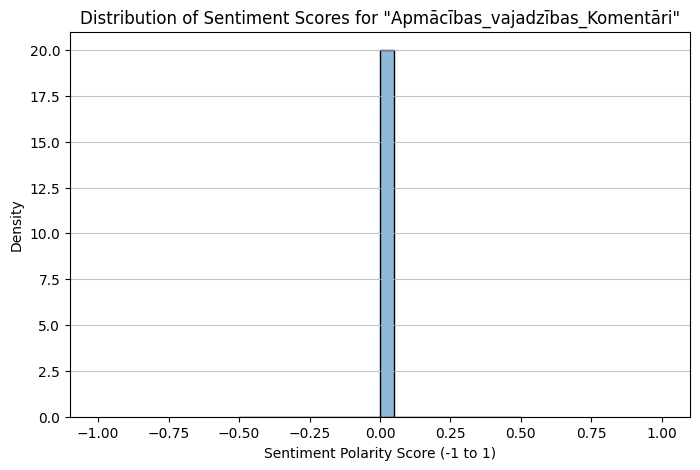

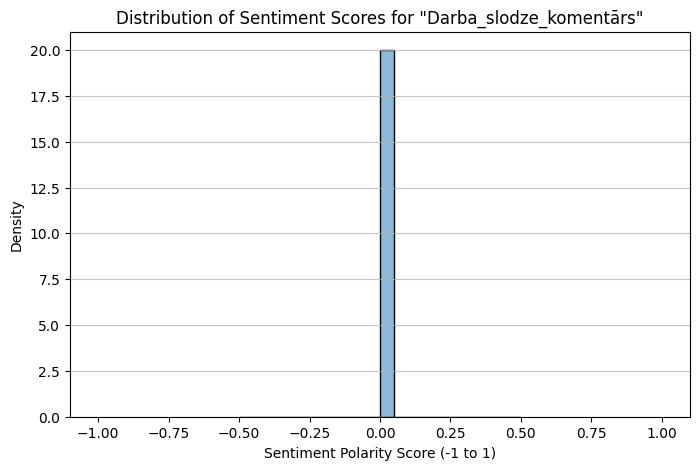

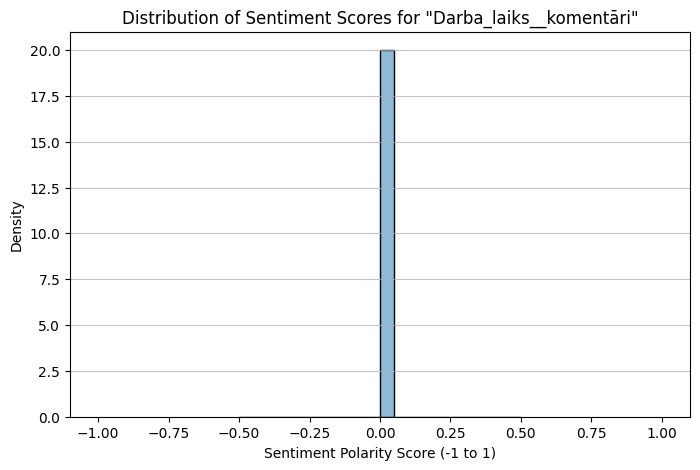

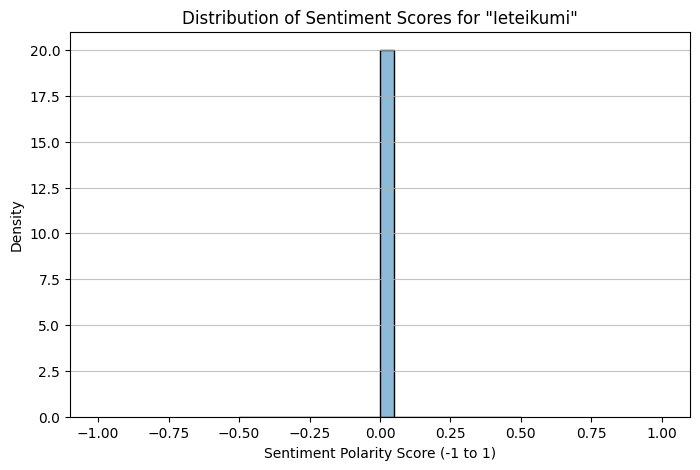

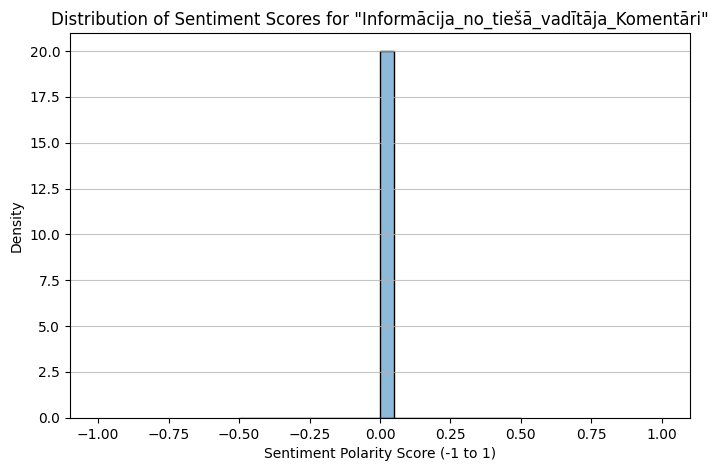

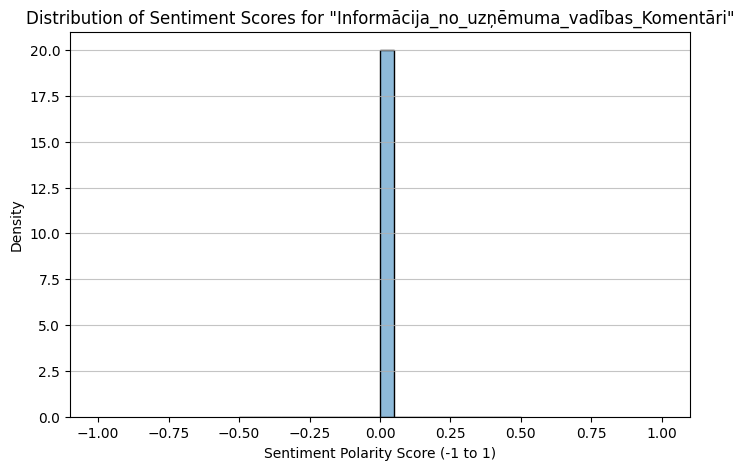

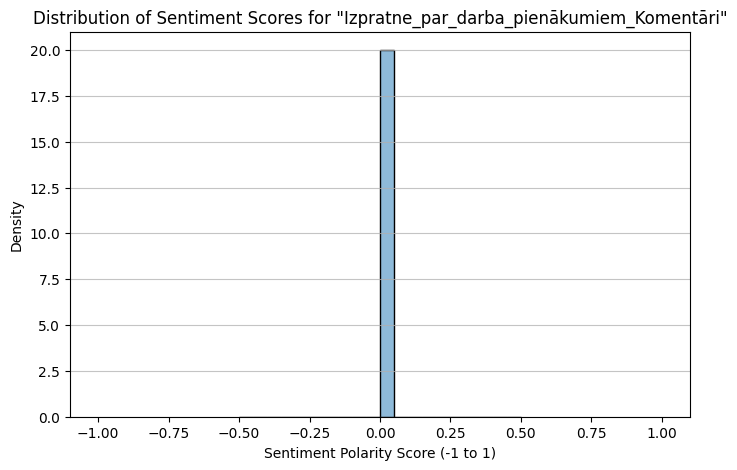

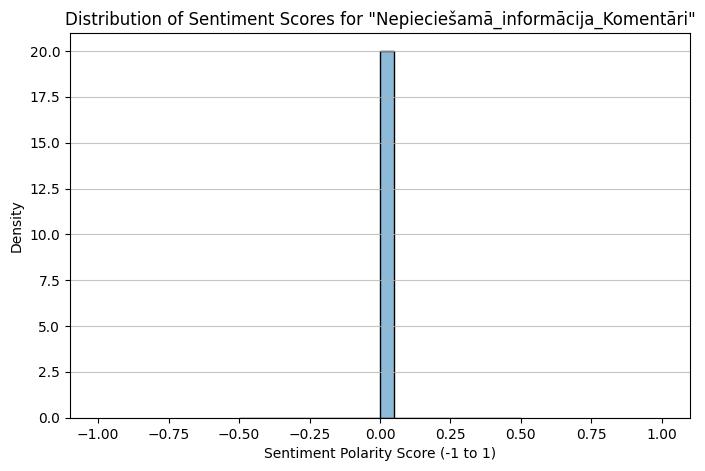

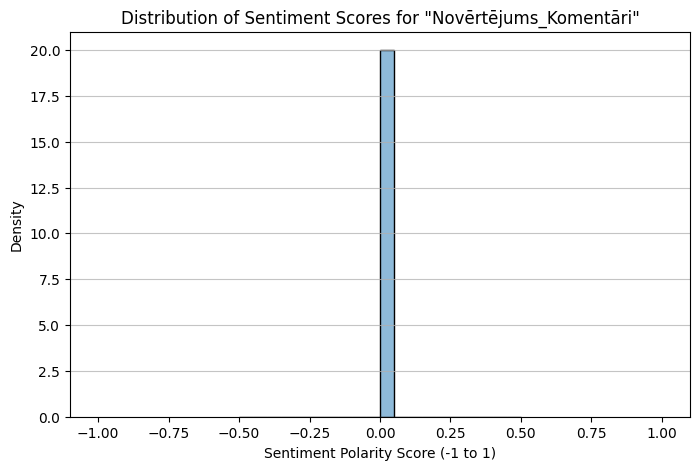

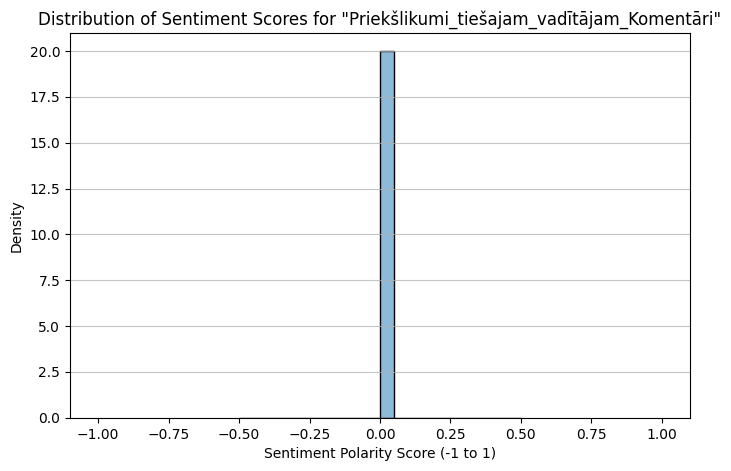

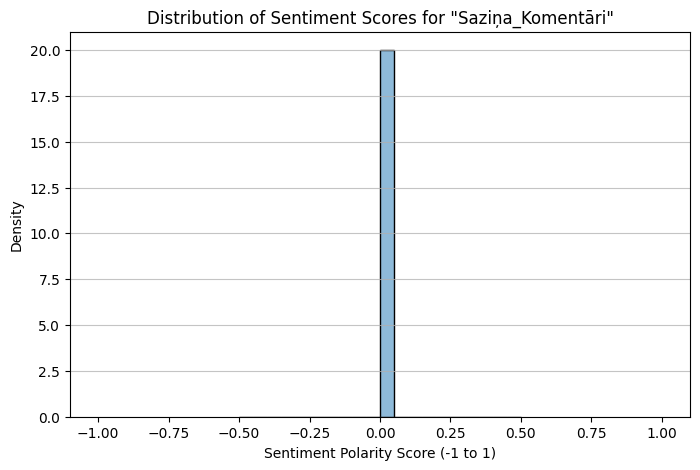

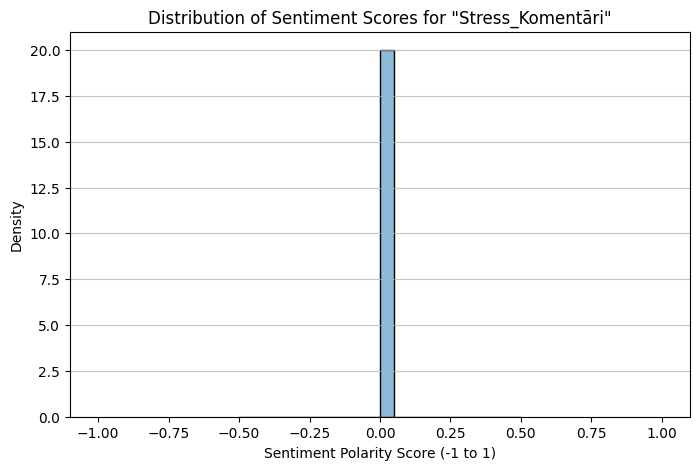

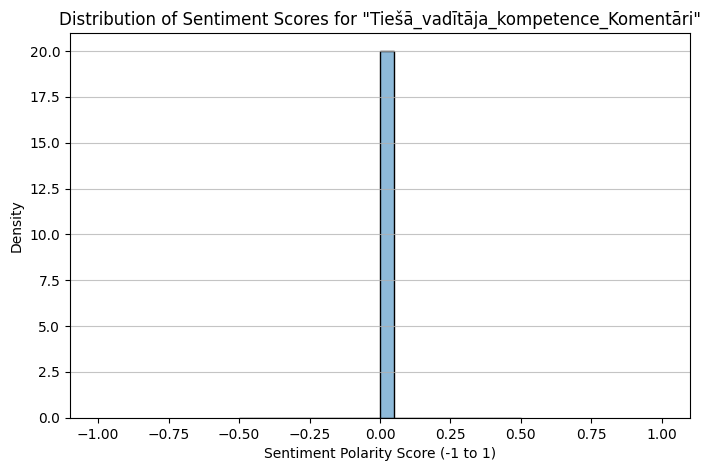

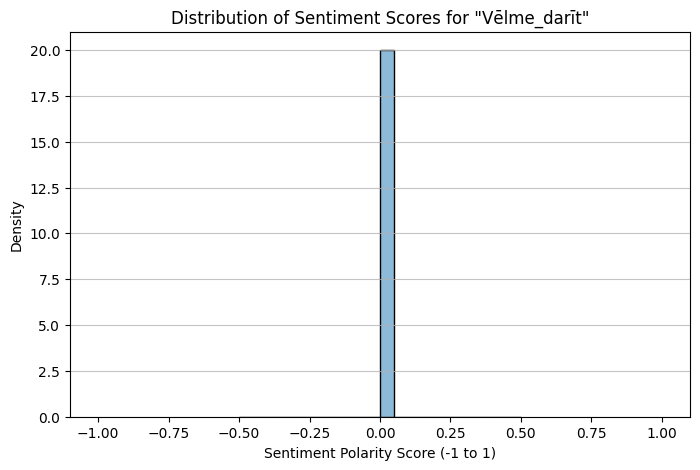

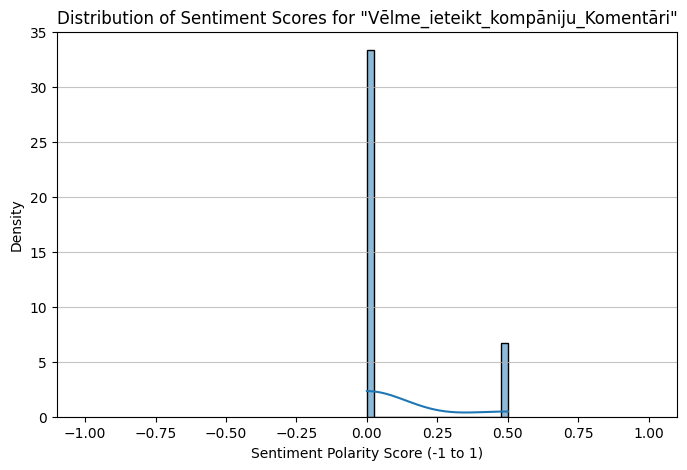

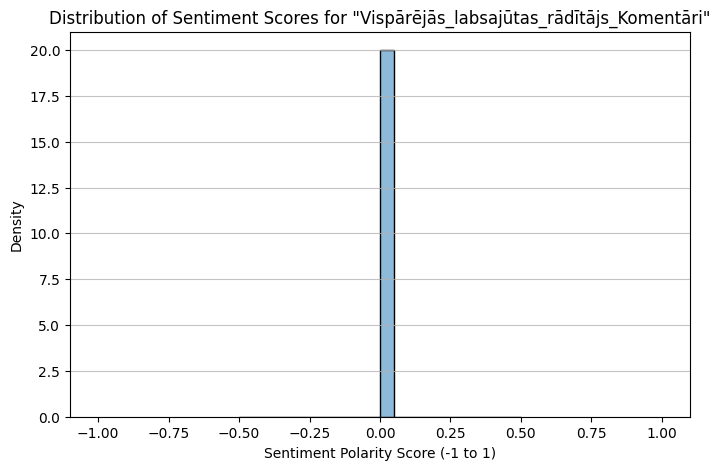

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'merged_data' DataFrame is available and contains sentiment columns
# from the previous TextBlob processing step.
# Also assuming 'text_columns_to_clean' list is defined.

# List of sentiment column names
sentiment_cols = [f'{col}_sentiment' for col in text_columns_to_clean if f'{col}_sentiment' in merged_data.columns]

# Plotting histograms for each sentiment column
for sentiment_col in sentiment_cols:
    plt.figure(figsize=(8, 5))
    # Use `dropna=True` to exclude None values if there are any missing sentiments
    sns.histplot(data=merged_data, x=sentiment_col, kde=True, bins=20, stat="density", common_norm=False)
    plt.title(f'Distribution of Sentiment Scores for "{sentiment_col.replace("_sentiment", "")}"')
    plt.xlabel('Sentiment Polarity Score (-1 to 1)')
    plt.ylabel('Density') # Using density to make comparison easier if distributions differ
    plt.xlim(-1.1, 1.1) # Set x-axis limits to clearly show the -1 to 1 range
    plt.grid(axis='y', alpha=0.75)
    plt.show()

In [71]:
# prompt: describe and give overview of sentiments of Vēlme_ieteikt_kompāniju_Komentāri_sentiment,  Ieteikumi_sentiment, dtype, Vēlme_darīt_sentiment.

import matplotlib.pyplot as plt
# Describe the sentiment columns and their overview
sentiment_cols_to_describe = [
    'Vēlme_ieteikt_kompāniju_Komentāri_sentiment',
    'Ieteikumi_sentiment',
    'Vēlme_darīt_sentiment'
]

# Ensure the columns exist in the merged_data DataFrame
sentiment_cols_present = [col for col in sentiment_cols_to_describe if col in merged_data.columns]

if not sentiment_cols_present:
    print("None of the specified sentiment columns were found in the DataFrame.")
else:
    print("Overview and description of specified sentiment columns:")

    for col in sentiment_cols_present:
        print(f"\n--- Description for '{col}' ---")

        # Data type
        print(f"Data type (dtype): {merged_data[col].dtype}")

        # Basic statistics (min, max, mean, std, count)
        print("Basic Statistics:")
        print(merged_data[col].describe())

        # Number of non-null values
        non_null_count = merged_data[col].count()
        total_count = len(merged_data)
        print(f"Non-null values: {non_null_count} out of {total_count}")

        # Value counts (especially useful for understanding distribution, though sentiment is continuous)
        # For a continuous variable like sentiment, value counts might be less informative unless binned.
        # Instead, we can look at the distribution of positive, negative, and neutral sentiments.
        if merged_data[col].dtype == 'float64' or merged_data[col].dtype == 'float32': # Check if it's a numeric sentiment score
            print("\nSentiment Distribution (Approximation):")
            positive_sentiment = (merged_data[col] > 0).sum()
            negative_sentiment = (merged_data[col] < 0).sum()
            neutral_sentiment = (merged_data[col] == 0).sum()
            missing_sentiment = merged_data[col].isnull().sum()

            print(f"Positive (> 0): {positive_sentiment} ({positive_sentiment/total_count:.2%})")
            print(f"Negative (< 0): {negative_sentiment} ({negative_sentiment/total_count:.2%})")
            print(f"Neutral (= 0): {neutral_sentiment} ({neutral_sentiment/total_count:.2%})")
            print(f"Missing (NaN): {missing_sentiment} ({missing_sentiment/total_count:.2%})")

            # Optional: Visualize the sentiment distribution for these specific columns
            plt.figure(figsize=(8, 5))
            sns.histplot(data=merged_data, x=col, kde=True, bins=20, stat="density", common_norm=False)
            plt.title(f'Distribution of Sentiment Scores for "{col.replace("_sentiment", "")}"')
            plt.xlabel('Sentiment Polarity Score (-1 to 1)')
            plt.ylabel('Density')
            plt.xlim(-1.1, 1.1)
            plt.grid(axis='y', alpha=0.75)
            plt.show()

        else:
            # If for some reason the sentiment column is not numeric (e.g., if TextBlob failed unexpectedly)
            print("Sentiment column does not appear to be purely numeric.")
            print(merged_data[col].value_counts(dropna=False))



None of the specified sentiment columns were found in the DataFrame.


In [ ]:
# Define the description content as a string
sentiment_description_content = """
## Sentiment Analysis Components

This document describes the components related to the sentiment analysis performed on the employee feedback data, as implemented in the provided Python code.

**1. Original Text Columns Analyzed:**

Sentiment analysis was applied to the following unstructured text columns from the original dataset (present in the `merged_data` DataFrame after merging structured and unstructured data). These columns contain employee feedback comments:

*   `Apmācības_vajadzības_Komentāri`
*   `Darba_slodze_komentārs`
*   `Darba_laiks__komentāri`
*   `Ieteikumi`
*   `Informācija_no_tiešā_vadītāja_Komentāri`
*   `Informācija_no_uzņēmuma_vadības_Komentāri`
*   `Izpratne_par_darba_pienākumiem_Komentāri`
*   `Nepieciešamā_informācija_Komentāri`
*   `Novērtējums_Komentāri`
*   `Priekšlikumi_tiešajam_vadītājam_Komentāri`
*   `Saziņa_Komentāri`
*   `Stress_Komentāri`
*   `Tiešā_vadītāja_kompetence_Komentāri`
*   `Vēlme_darīt`
*   `Vēlme_ieteikt_kompāniju_Komentāri`
*   `Vispārējās_labsajūtas_rādītājs_Komentāri`

**2. Calculated Sentiment Score Columns:**

For each of the original text columns listed above, a new column was added to the `merged_data` DataFrame containing the sentiment polarity score. The naming convention for these new columns is the original text column name followed by `_sentiment`. The sentiment score is a floating-point number typically ranging from -1 (most negative) to 1 (most positive). The sentiment columns created are:

*   `Apmācības_vajadzības_Komentāri_sentiment`
*   `Darba_slodze_komentārs_sentiment`
*   `Darba_laiks__komentāri_sentiment`
*   `Ieteikumi_sentiment`
*   `Informācija_no_tiešā_vadītāja_Komentāri_sentiment`
*   `Informācija_no_uzņēmuma_vadības_Komentāri_sentiment`
*   `Izpratne_par_darba_pienākumiem_Komentāri_sentiment`
*   `Nepieciešamā_informācija_Komentāri_sentiment`
*   `Novērtējums_Komentāri_sentiment`
*   `Priekšlikumi_tiešajam_vadītājam_Komentāri_sentiment`
*   `Saziņa_Komentāri_sentiment`
*   `Stress_Komentāri_sentiment`
*   `Tiešā_vadītāja_kompetence_Komentāri_sentiment`
*   `Vēlme_darīt_sentiment`
*   `Vēlme_ieteikt_kompāniju_Komentāri_sentiment`
*   `Vispārējās_labsajūtas_rādītājs_Komentāri_sentiment`

**3. Sentiment Analysis Method:**

The sentiment analysis was performed using the `TextBlob` library in Python. Specifically, the `sentiment.polarity` attribute of a `TextBlob` object was used to obtain the sentiment score for each text entry.

**4. Sentiment Classification Thresholds:**

For the purpose of providing an overview and classifying sentiments into broad categories (Positive, Neutral, Negative), the following thresholds were used:

*   **Positive Sentiment:** Sentiment score > 0.1
*   **Negative Sentiment:** Sentiment score < -0.1
*   **Neutral Sentiment:** Sentiment score is within the range [-0.1, 0.1] (inclusive of -0.1 and 0.1)

These components represent how sentiment was extracted, stored, and interpreted in the analysis based on the provided code.
"""

# Define the filename
filename = 'sentiment_analysis_description.txt'

# Write the content to the file
with open(filename, 'w') as f:
    f.write(sentiment_description_content)

# For Jupyter Notebook environments, you can use IPython.display to offer a download link
from IPython.display import FileLink, display

print(f"Description saved to {filename}")

# Create a clickable link to download the file
display(FileLink(filename))

Description saved to sentiment_analysis_description.txt


/content/sentiment_analysis_description.txt

In [ ]:
# Consistency across datasets (Structured and Unstructured):
# 'Respondent ID' is the common identifier
# Merge the datasets based on 'Respondent ID'
merged_data = pd.merge(structured_data, unstructured_data, on='Respondent_ID', how='left')

# Check for inconsistencies in employee IDs
if not merged_data.empty:
    id_mismatches = merged_data[merged_data['Respondent_ID'].isnull()]
    if not id_mismatches.empty:
        print("Inconsistencies found in Respondent IDs:")
        print(id_mismatches)
    else:
        print("No inconsistencies found in Respondent IDs.")
else:
    print("No data found in the merged dataset")

No inconsistencies found in Respondent IDs.


Original structured data shape: (54, 36)
Processed structured data shape (with one-hot encoding for all specified cats): (54, 233)
First few rows of the processed data:
   Respondent_ID  Vispārējās_labsajūtas_rādītājs  Apmācības_vajadzības_Cits  \
0              1                               9                        0.0   
1              2                               8                        0.0   
2              3                               9                        0.0   
3              4                               9                        0.0   
4              5                               9                        1.0   

   Apmācības_vajadzības_Cits: Varētu ik pa laikam ka'dus kursus apmeklēt  \
0                                                0.0                       
1                                                0.0                       
2                                                0.0                       
3                                                0.0

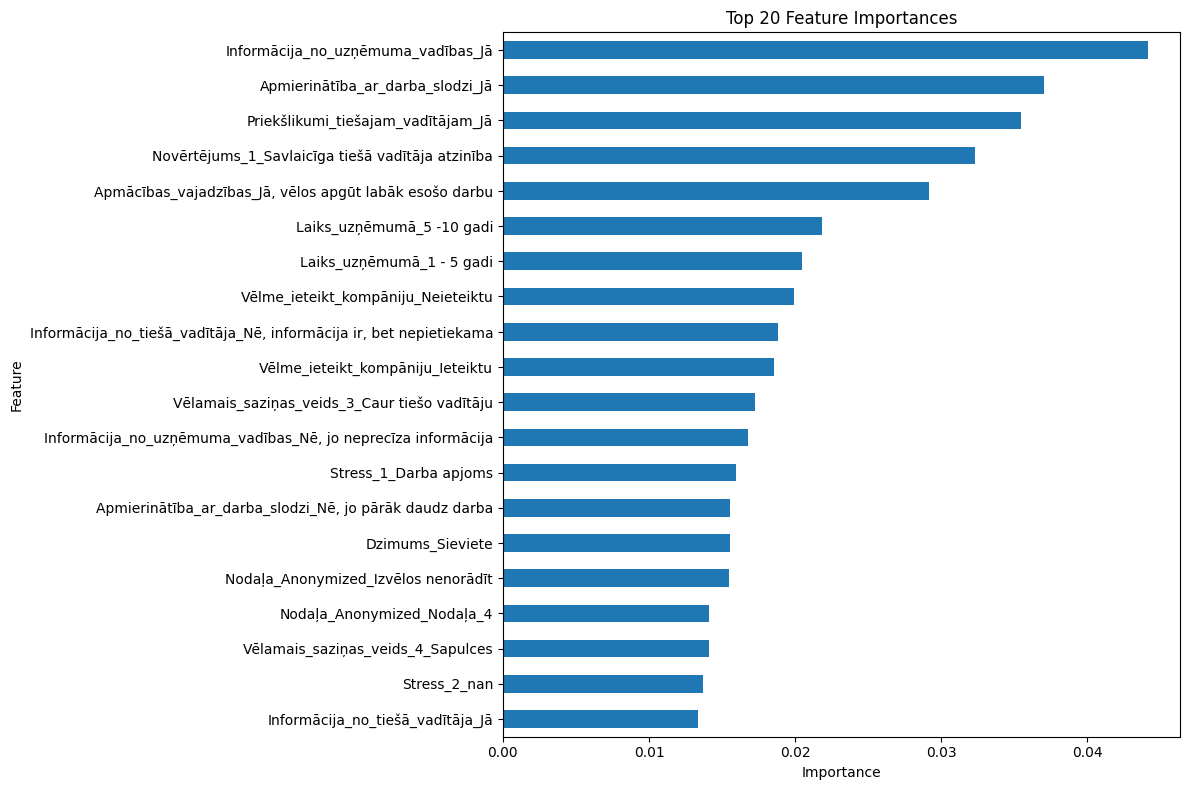


Top 20 Permutation Importances (Random Forest on Test Set):
Priekšlikumi_tiešajam_vadītājam_Jā                                                                                                                                                              0.071429
Apmierinātība_ar_darba_slodzi_Jā                                                                                                                                                                0.064286
Apmierinātība_ar_darba_slodzi_Nē, jo pārāk ātri jāstrādā                                                                                                                                        0.057143
Informācija_no_uzņēmuma_vadības_Jā                                                                                                                                                              0.057143
Laiks_uzņēmumā_5 -10 gadi                                                                                                              

<ipython-input-59-0682567d71b0>:228: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


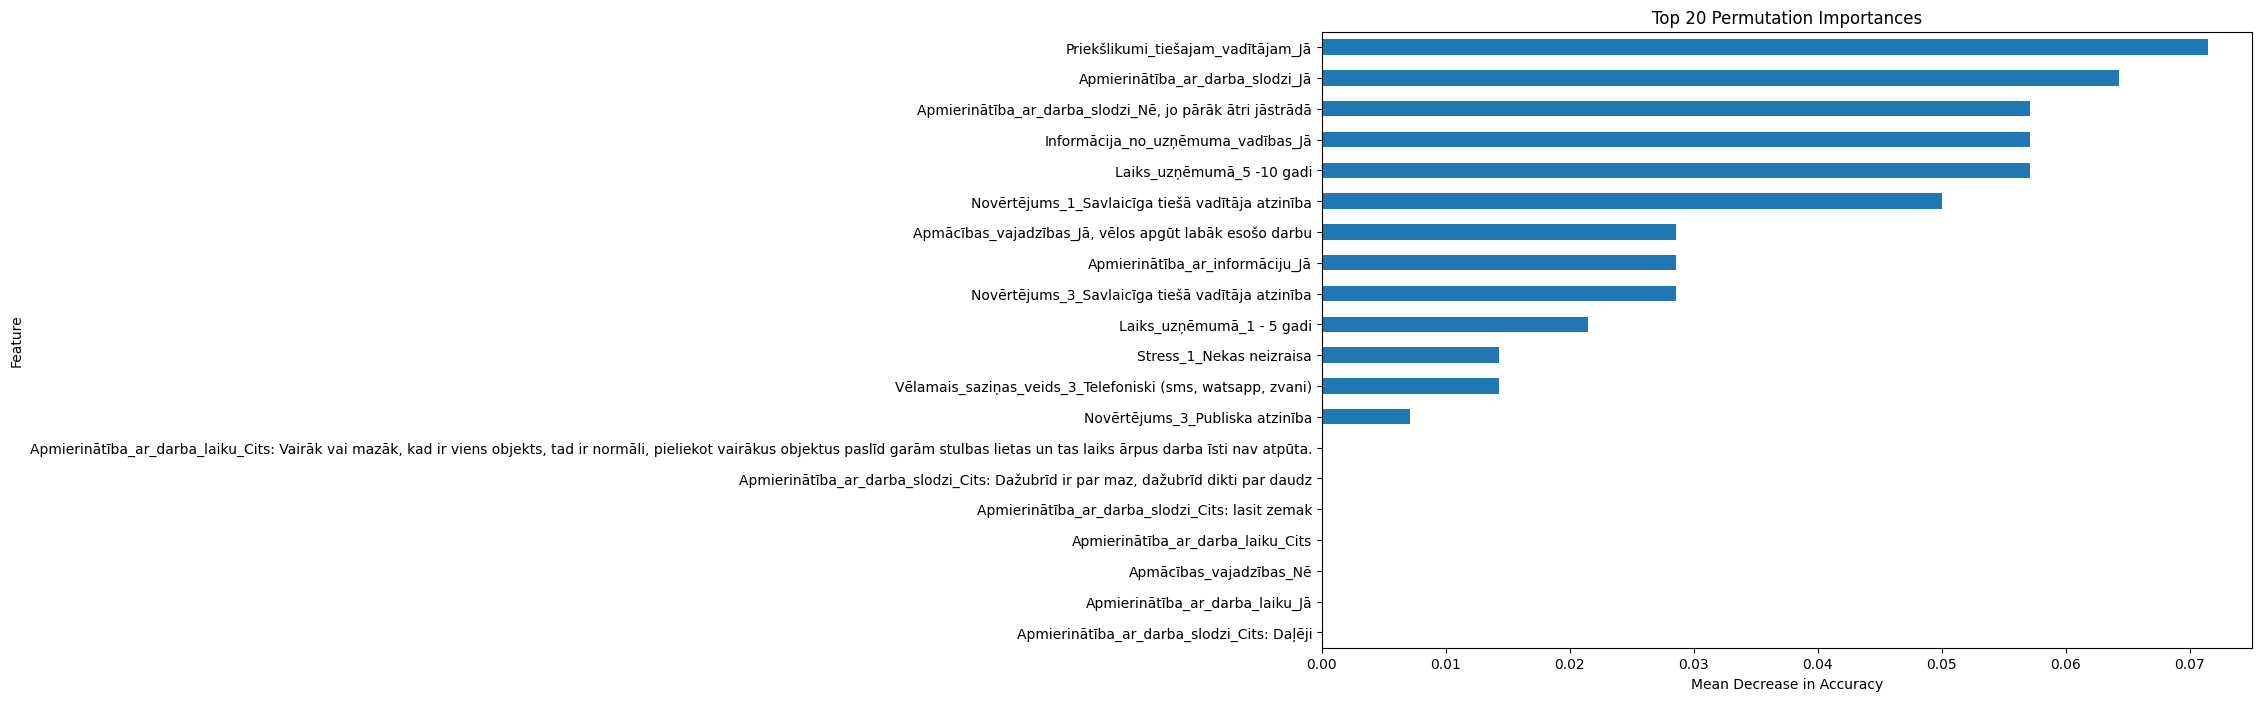

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt # Keep imports needed for plotting feature importances
from sklearn.tree import DecisionTreeClassifier # Keep model imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from textblob import TextBlob # Keep TextBlob import if using sentiment

# Make sure structured_data and merged_data are loaded or created from previous steps
# (Assuming they are available from the previous cells)

# Identify all categorical columns based on the provided list
# Include 'Nodaļa_Anonymized' in the list of columns to be encoded
all_categorical_columns_to_encode = [
    'Apmācības_vajadzības',
    'Apmierinātība_ar_darba_laiku',
    'Apmierinātība_ar_darba_slodzi',
    'Apmierinātība_ar_informāciju',
    'Dzimums',
    'formid', # Assuming 'formid' is categorical and needs encoding
    'Informācija_no_tiešā_vadītāja',
    'Informācija_no_uzņēmuma_vadības',
    'Izpratne_par_darba_pienākumiem',
    'Laiks_uzņēmumā',
    'Novērtējums_1',
    'Novērtējums_2',
    'Novērtējums_3',
    'Novērtējums_4',
    'Novērtējums_5',
    'Novērtējums_6',
    'Novērtējums_7',
    'Priekšlikumi_tiešajam_vadītājam',
    'sent', # Assuming 'sent' is categorical and needs encoding
    'Stress_1',
    'Stress_2',
    'Stress_3',
    'Stress_4',
    'Stress_5',
    'Stress_6',
    'Stress_7',
    'Tiešā_vadītāja_kompetence',
    'Vēlamais_saziņas_veids_1',
    'Vēlamais_saziņas_veids_2',
    'Vēlamais_saziņas_veids_3',
    'Vēlamais_saziņas_veids_4',
    'Vēlamais_saziņas_veids_5',
    'Vēlme_ieteikt_kompāniju',
    'Nodaļa_Anonymized' # Include Nodaļa_Anonymized here
]

# Ensure the columns actually exist in the DataFrame
columns_to_encode_present = [col for col in all_categorical_columns_to_encode if col in structured_data.columns]

# Apply One-Hot Encoding to the selected columns
# Use handle_unknown='ignore' to handle potential categories not seen during fit
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_categorical_features = one_hot_encoder.fit_transform(structured_data[columns_to_encode_present])

# Create a DataFrame from the encoded features
encoded_feature_names = one_hot_encoder.get_feature_names_out(columns_to_encode_present)
structured_data_encoded = pd.DataFrame(encoded_categorical_features, columns=encoded_feature_names, index=structured_data.index)

# Drop the original categorical columns that were encoded
# Keep only the columns that were NOT in the list of columns to encode, plus the new encoded columns
original_cols_to_keep = [col for col in structured_data.columns if col not in columns_to_encode_present]

structured_data_processed = pd.concat([structured_data[original_cols_to_keep], structured_data_encoded], axis=1)


print("Original structured data shape:", structured_data.shape)
print("Processed structured data shape (with one-hot encoding for all specified cats):", structured_data_processed.shape)
print("First few rows of the processed data:")
print(structured_data_processed.head())

# --- Continue with the rest of your ML preparation steps ---

# Define the target variable (assuming a binary classification problem)
# Let's create a binary target: 1 if well-being score is 8 or higher, 0 otherwise.
# Use the original 'Vispārējās_labsajūtas_rādītājs' column before any potential removal of rows during validation or scaling.
# Ensure 'Vispārējās_labsajūtas_rādītājs' is numeric
# Need to ensure structured_data still contains this column and is correctly indexed after any previous steps
# Re-load or re-create structured_data if necessary, ensuring validation steps are applied.
# For this fix, we assume structured_data is the dataframe after cleaning and validation,
# but before the *failed* encoding step.

# Ensure 'Vispārējās_labsajūtas_rādītājs' is numeric
structured_data['Vispārējās_labsajūtas_rādītājs'] = pd.to_numeric(structured_data['Vispārējās_labsajūtas_rādītājs'], errors='coerce')

# Handle potential NaNs introduced by conversion
# For the target, it's best to drop rows where the target is missing.
structured_data.dropna(subset=['Vispārējās_labsajūtas_rādītājs'], inplace=True)

# Align the indices of the processed features DataFrame (`structured_data_processed`)
# with the target Series. This is crucial if any rows were dropped from the original data.
# We should re-create the target based on the potentially filtered 'structured_data'
# after handling NaNs in the target column.

# Re-index structured_data_processed to match the potentially filtered structured_data
structured_data_processed = structured_data_processed.loc[structured_data.index]

# Create the target variable based on the filtered structured_data
# Ensure the target is also a pandas Series with the same index as the features
y = (structured_data['Vispārējās_labsajūtas_rādītājs'] >= 8).astype(int) # Binary target: 1 for score >= 8, 0 otherwise

# Now, prepare the feature matrix X.
# 'structured_data_processed' contains the features (numerical and one-hot encoded categorical).
X = structured_data_processed.copy()

# Optional: Include sentiment scores as features.
# The sentiment scores are in 'merged_data'.
# Ensure 'merged_data' is also aligned with the filtered structured_data
# If merged_data doesn't exist or isn't aligned, you might need to re-merge or re-load.
# Assuming merged_data_aligned from previous successful cells is available and aligned.
merged_data_aligned = merged_data.loc[structured_data.index]


sentiment_features = [col for col in merged_data_aligned.columns if '_sentiment' in col]

# Select the sentiment columns and handle any potential NaNs in sentiment scores
# You might replace NaNs with 0 or the mean, depending on how you want to treat missing sentiment.
X_sentiment = merged_data_aligned[sentiment_features].fillna(0) # Example: Fill missing sentiment with 0

# Concatenate sentiment features with the existing features
# Ensure no duplicate column names if sentiment columns have same names as others
X = pd.concat([X, X_sentiment], axis=1)

# Remove columns that should not be features (e.g., original wellbeing score, Respondent ID)
cols_to_drop_from_features = [
    'Vispārējās_labsajūtas_rādītājs',
    'Normalized Wellbeing Score', # Drop if it was added separately and you are using binary target
    'Respondent_ID' # Drop identifier
    ]

# Drop columns from X if they exist
X = X.drop(columns=[col for col in cols_to_drop_from_features if col in X.columns])


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Shape of X_train after fixing encoding:", X_train.shape)
print("Shape of X_test after fixing encoding:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# --- Example ML Model Implementation (Decision Tree Classifier) ---

# Initialize a Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train) # This line should now work

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model (example using accuracy)
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("\nDecision Tree Classifier Results:")
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- Example ML Model Implementation (Random Forest Classifier) ---

# Initialize a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # You can tune n_estimators

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_y_pred = rf_model.predict(X_test)

# Evaluate the Random Forest model
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print("\nRandom Forest Classifier Results:")
print(f"Accuracy: {rf_accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_y_pred))

# --- Feature Importance (using the trained Random Forest model) ---

# Calculate feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Sort the importances and take the top N
top_n = 20 # Display top 20 features
sorted_importances = feature_importances.sort_values(ascending=False).head(top_n)

print(f"\nTop {top_n} Feature Importances (Random Forest):")
print(sorted_importances)

# Visualize feature importances
plt.figure(figsize=(12, 8))
sorted_importances.plot(kind='barh')
plt.title(f'Top {top_n} Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Display the most important at the top
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# --- Permutation Importance (alternative way to assess importance) ---
# Permutation importance can be more reliable as it measures impact on model performance

result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores

# Store the importances in a Series
perm_importances = pd.Series(result.importances_mean, index=X_test.columns)

# Sort and display top N
sorted_perm_importances = perm_importances.sort_values(ascending=False).head(top_n)

print(f"\nTop {top_n} Permutation Importances (Random Forest on Test Set):")
print(sorted_perm_importances)

# Visualize permutation importances
plt.figure(figsize=(12, 8))
sorted_perm_importances.plot(kind='barh')
plt.title(f'Top {top_n} Permutation Importances')
plt.xlabel('Mean Decrease in Accuracy')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- Further Steps ---
# 1. Model Selection and Tuning: Experiment with different models (e.g., Logistic Regression, SVM, Gradient Boosting like XGBoost or LightGBM)
#    and tune their hyperparameters using techniques like GridSearchCV or RandomSearchCV.
# 2. Cross-Validation: Use cross-validation to get a more robust estimate of your model's performance.
# 3. More Advanced Feature Engineering:
#    - Explore N-grams or TF-IDF for the text data.
#    - Create interaction terms between features.
#    - Consider dimensionality reduction techniques (e.g., PCA) if you have many features.
# 4. Handling Class Imbalance: If the number of samples in the 'High Well-being' class is much smaller than the 'Low Well-being' class,
#    you might need techniques like oversampling (SMOTE) or undersampling, or use evaluation metrics like F1-score, precision, and recall,
#    which are less sensitive to imbalance than accuracy.
# 5. Regression vs. Classification: If predicting the exact well-being score is more useful, switch to regression models (e.g., Linear Regression, Ridge, Lasso, Regression Trees, etc.)
#    and use appropriate evaluation metrics (e.g., Mean Absolute Error, Mean Squared Error, R-squared).
# 6. Ontology Integration: The project mentions Ontology Generation. How would the ontology be used? It could potentially
#    help in identifying related terms in text data, structuring relationships between concepts (like 'workload' and 'stress'),
#    which could lead to new engineered features or a more semantic understanding of the data. This wasn't implemented in the code provided, but it's mentioned in the document.

In [ ]:
# prompt: i want to load preprocesed data set for future use

import pandas as pd
# The preprocessed data is available in the following DataFrames:
# - `structured_data_encoded`: Structured data with numerical features scaled and categorical features one-hot encoded.
# - `merged_data`: Contains original structured and unstructured data, including sentiment scores.
# - `X`: The feature matrix prepared for the ML model, including encoded structured features and selected sentiment features.
# - `y`: The target variable (binary classification for well-being score >= 8).

# You can save these DataFrames to disk for future use without re-running the preprocessing steps.
# Common formats are CSV, Parquet, or Pickle. Parquet is often preferred for larger datasets.

# Save the processed features (X) and target (y)
X.to_parquet('processed_features_X.parquet')
y.to_csv('processed_target_y.csv', index=False)

print("Processed features (X) saved to 'processed_features_X.parquet'")
print("Processed target (y) saved to 'processed_target_y.csv'")

# You could also save the entire merged_data if you want to retain all information
# merged_data.to_parquet('processed_merged_data.parquet')
# print("Processed merged data saved to 'processed_merged_data.parquet'")


# To load the data in a future session:
# loaded_X = pd.read_parquet('processed_features_X.parquet')
# loaded_y = pd.read_csv('processed_target_y.csv')
# loaded_merged_data = pd.read_parquet('processed_merged_data.parquet') # If you saved it

# print("\nData loaded from files:")
# print("Loaded X shape:", loaded_X.shape)
# print("Loaded y shape:", loaded_y.shape)
# print("Loaded merged data shape (if saved):", loaded_merged_data.shape if 'loaded_merged_data' in locals() else "Not saved")


Processed features (X) saved to 'processed_features_X.parquet'
Processed target (y) saved to 'processed_target_y.csv'


Shape of X_train: (40, 247)
Shape of X_test: (14, 247)
Shape of y_train: (40,)
Shape of y_test: (14,)

Decision Tree Classifier Results:
Accuracy: 0.71

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         4
           1       1.00      0.60      0.75        10

    accuracy                           0.71        14
   macro avg       0.75      0.80      0.71        14
weighted avg       0.86      0.71      0.73        14


Random Forest Classifier Results:
Accuracy: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.91      1.00      0.95        10

    accuracy                           0.93        14
   macro avg       0.95      0.88      0.90        14
weighted avg       0.94      0.93      0.93        14


Top 20 Feature Importances (Random Forest):
Apmierinātība_ar_darba_slodzi_Jā                   

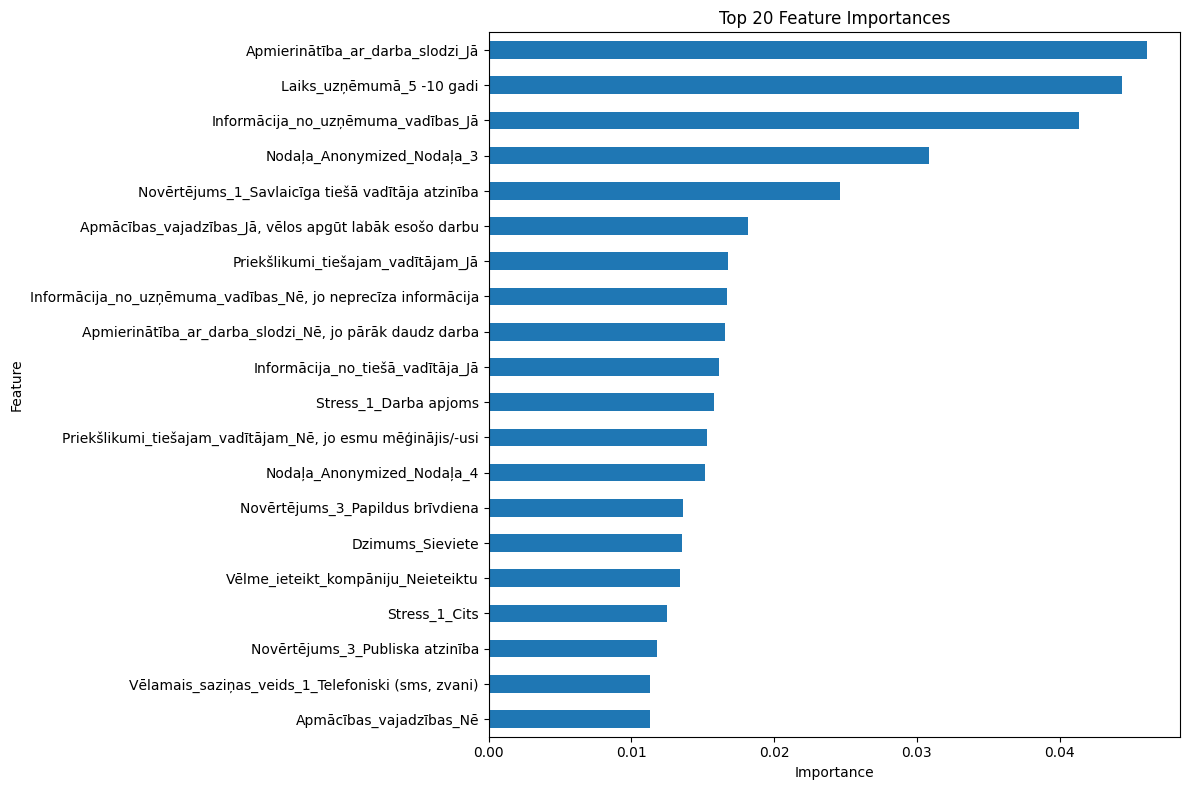


Top 20 Permutation Importances (Random Forest on Test Set):
Laiks_uzņēmumā_5 -10 gadi                                                                                                                                                                       0.107143
Vēlamais_saziņas_veids_1_Sapulces                                                                                                                                                               0.050000
Stress_2_nan                                                                                                                                                                                    0.035714
Apmierinātība_ar_darba_slodzi_Jā                                                                                                                                                                0.028571
Vēlamais_saziņas_veids_3_nan                                                                                                           

<ipython-input-33-18229329aea6>:168: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


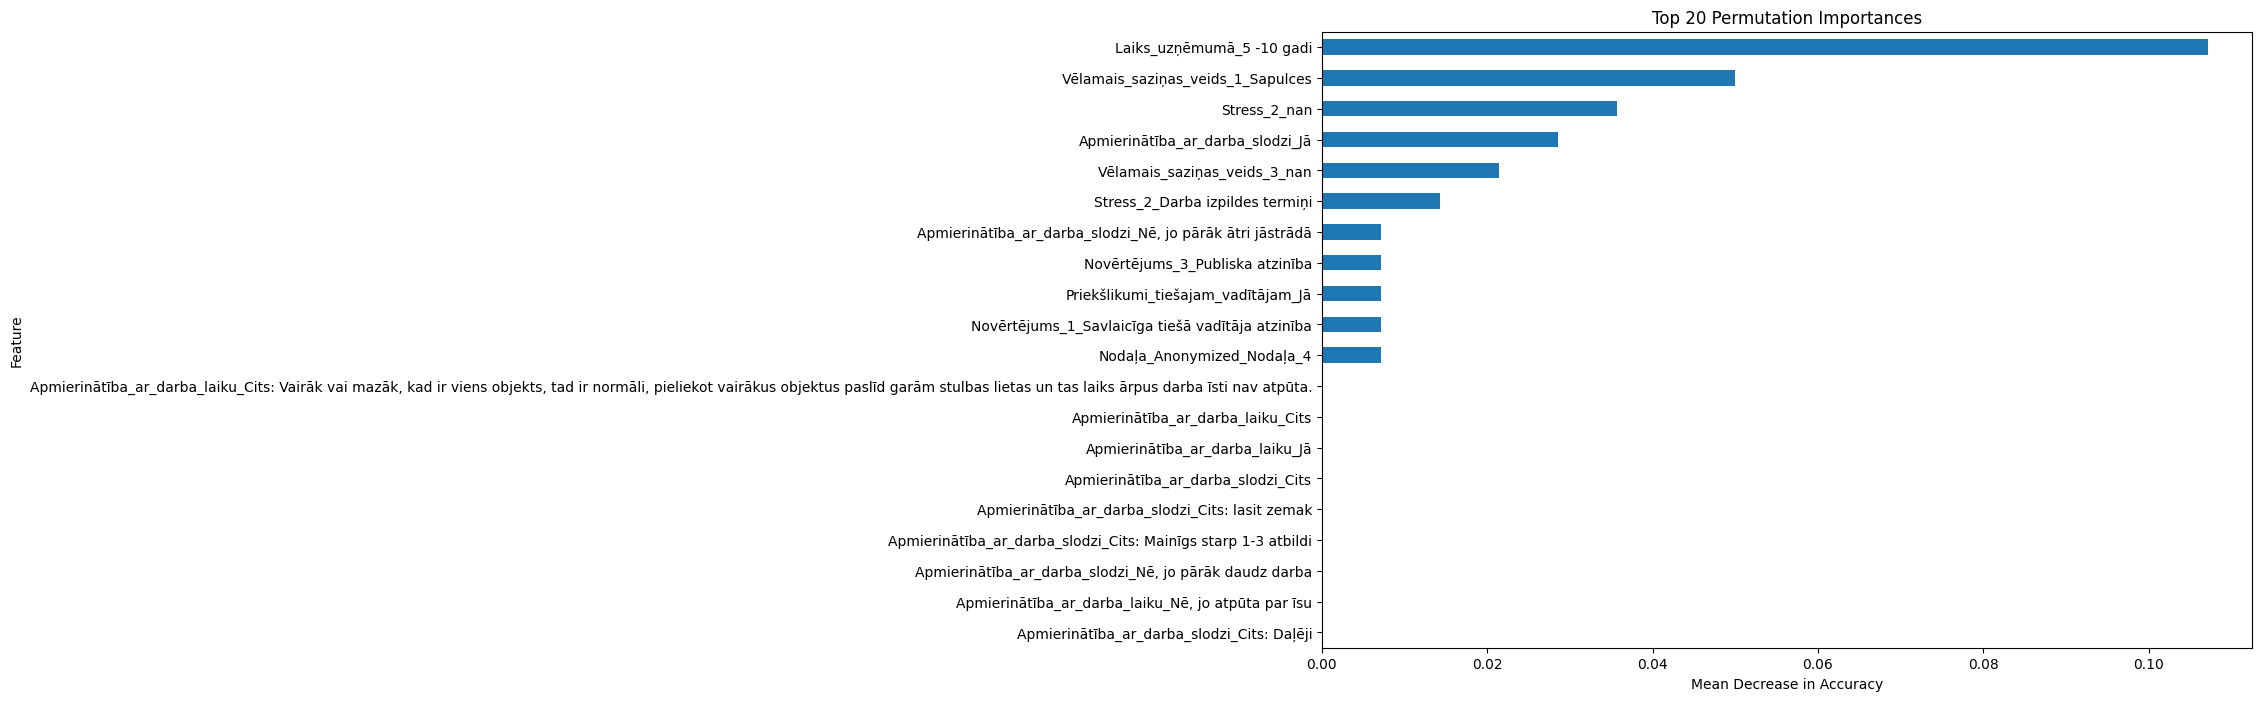

In [ ]:
# prompt: how touse this created data to ml models

import pandas as pd
import matplotlib.pyplot as plt
# Now you have 'structured_data_encoded' which contains your preprocessed and encoded features.
# You also have sentiment scores in 'merged_data'.
# To use this data in ML models, you first need to define your target variable (the variable you want to predict).
# Based on the problem description, 'Vispārējās_labsajūtas_rādītājs' (Well-being Score) is a likely candidate.
# You could treat this as a regression problem (predicting the score directly)
# or a classification problem (e.g., classifying into 'Low', 'Medium', 'High' well-being).

# Let's assume we're aiming for a classification problem, maybe predicting if well-being is above a certain threshold (e.g., > 7).
# First, ensure the 'Vispārējās_labsajsajūtas_rādītājs' is in your final feature set or linked correctly.
# The 'structured_data_encoded' should already contain a scaled version or the original if not scaled.
# Let's use the 'Vispārējās_labsajūtas_rādītājs' column from the original structured_data
# to create a binary target variable.

# Define the target variable (assuming a binary classification problem)
# Let's create a binary target: 1 if well-being score is 8 or higher, 0 otherwise.
# Use the original 'Vispārējās_labsajūtas_rādītājs' column before any potential removal of rows during validation or scaling.
# Ensure 'Vispārējās_labsajūtas_rādītājs' is numeric
structured_data['Vispārējās_labsajūtas_rādītājs'] = pd.to_numeric(structured_data['Vispārējās_labsajūtas_rādītājs'], errors='coerce')

# Handle potential NaNs introduced by conversion
# For the target, it's best to drop rows where the target is missing.
structured_data.dropna(subset=['Vispārējās_labsajūtas_rādītājs'], inplace=True)

# Align the indices of the features DataFrame ('structured_data_encoded') with the target Series.
# This is crucial if any rows were dropped from the original data.
# We should re-create the target based on the potentially filtered 'structured_data'
# after handling NaNs in the target column.

# Re-index structured_data_encoded to match the potentially filtered structured_data
structured_data_encoded = structured_data_encoded.loc[structured_data.index]

# Create the target variable based on the filtered structured_data
# Ensure the target is also a pandas Series with the same index as the features
y = (structured_data['Vispārējās_labsajūtas_rādītājs'] >= 8).astype(int) # Binary target: 1 for score >= 8, 0 otherwise


# Now, prepare the feature matrix X.
# 'structured_data_encoded' contains the features (numerical and one-hot encoded categorical).
X = structured_data_encoded.copy()

# Optional: Include sentiment scores as features.
# You need to decide which sentiment scores are relevant.
# The sentiment scores are in 'merged_data'.
# If you want to use them, you need to merge 'merged_data' with 'structured_data_encoded' or select the relevant sentiment columns
# and ensure their indices align with X and y.

# Let's select some sentiment columns from merged_data and align them.
# Ensure 'merged_data' is also aligned with the filtered structured_data
merged_data_aligned = merged_data.loc[structured_data.index]

sentiment_features = [col for col in merged_data_aligned.columns if '_sentiment' in col]

# Select the sentiment columns and handle any potential NaNs in sentiment scores
# You might replace NaNs with 0 or the mean, depending on how you want to treat missing sentiment.
X_sentiment = merged_data_aligned[sentiment_features].fillna(0) # Example: Fill missing sentiment with 0

# Concatenate sentiment features with the existing features
X = pd.concat([X, X_sentiment], axis=1)

# Remove the original 'Vispārējās_labsajūtas_rādītājs' column from features if it's still there
# and we are using the derived binary target 'y'.
if 'Vispārējās_labsajūtas_rādītājs' in X.columns:
    X = X.drop(columns=['Vispārējās_labsajūtas_rādītājs'])

# Also remove the 'Normalized Wellbeing Score' column if it was added to the features and we are using a binary target
if 'Normalized Wellbeing Score' in X.columns:
    X = X.drop(columns=['Normalized Wellbeing Score'])

# Drop any other original identifier columns that are not features
# Ensure 'Respondent_ID' is not a feature
if 'Respondent_ID' in X.columns:
    X = X.drop(columns=['Respondent_ID'])


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# --- Example ML Model Implementation (Decision Tree Classifier) ---

# Initialize a Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model (example using accuracy)
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("\nDecision Tree Classifier Results:")
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- Example ML Model Implementation (Random Forest Classifier) ---

# Initialize a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # You can tune n_estimators

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_y_pred = rf_model.predict(X_test)

# Evaluate the Random Forest model
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print("\nRandom Forest Classifier Results:")
print(f"Accuracy: {rf_accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_y_pred))

# --- Feature Importance (using the trained Random Forest model) ---

# Calculate feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Sort the importances and take the top N
top_n = 20 # Display top 20 features
sorted_importances = feature_importances.sort_values(ascending=False).head(top_n)

print(f"\nTop {top_n} Feature Importances (Random Forest):")
print(sorted_importances)

# Visualize feature importances
plt.figure(figsize=(12, 8))
sorted_importances.plot(kind='barh')
plt.title(f'Top {top_n} Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Display the most important at the top
plt.tight_layout()
plt.show()

# --- Permutation Importance (alternative way to assess importance) ---
# Permutation importance can be more reliable as it measures impact on model performance

result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores

# Store the importances in a Series
perm_importances = pd.Series(result.importances_mean, index=X_test.columns)

# Sort and display top N
sorted_perm_importances = perm_importances.sort_values(ascending=False).head(top_n)

print(f"\nTop {top_n} Permutation Importances (Random Forest on Test Set):")
print(sorted_perm_importances)

# Visualize permutation importances
plt.figure(figsize=(12, 8))
sorted_perm_importances.plot(kind='barh')
plt.title(f'Top {top_n} Permutation Importances')
plt.xlabel('Mean Decrease in Accuracy')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# --- Further Steps ---
# 1. Model Selection and Tuning: Experiment with different models (e.g., Logistic Regression, SVM, Gradient Boosting like XGBoost or LightGBM)
#    and tune their hyperparameters using techniques like GridSearchCV or RandomSearchCV.
# 2. Cross-Validation: Use cross-validation to get a more robust estimate of your model's performance.
# 3. More Advanced Feature Engineering:
#    - Explore N-grams or TF-IDF for the text data.
#    - Create interaction terms between features.
#    - Consider dimensionality reduction techniques (e.g., PCA) if you have many features.
# 4. Handling Class Imbalance: If the number of samples in the 'High Well-being' class is much smaller than the 'Low Well-being' class,
#    you might need techniques like oversampling (SMOTE) or undersampling, or use evaluation metrics like F1-score, precision, and recall,
#    which are less sensitive to imbalance than accuracy.
# 5. Regression vs. Classification: If predicting the exact well-being score is more useful, switch to regression models (e.g., Linear Regression, Ridge, Lasso, Regression Trees, etc.)
#    and use appropriate evaluation metrics (e.g., Mean Absolute Error, Mean Squared Error, R-squared).
# 6. Ontology Integration: The project mentions Ontology Generation. How would the ontology be used? It could potentially
#    help in identifying related terms in text data, structuring relationships between concepts (like 'workload' and 'stress'),
#    which could lead to new engineered features or a more semantic understanding of the data. This wasn't implemented in the code provided, but it's mentioned in the document.


Logistic Regression Classifier Results:
Accuracy: 0.86

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.90      0.90      0.90        10

    accuracy                           0.86        14
   macro avg       0.82      0.82      0.82        14
weighted avg       0.86      0.86      0.86        14


ROC AUC Score: 0.88


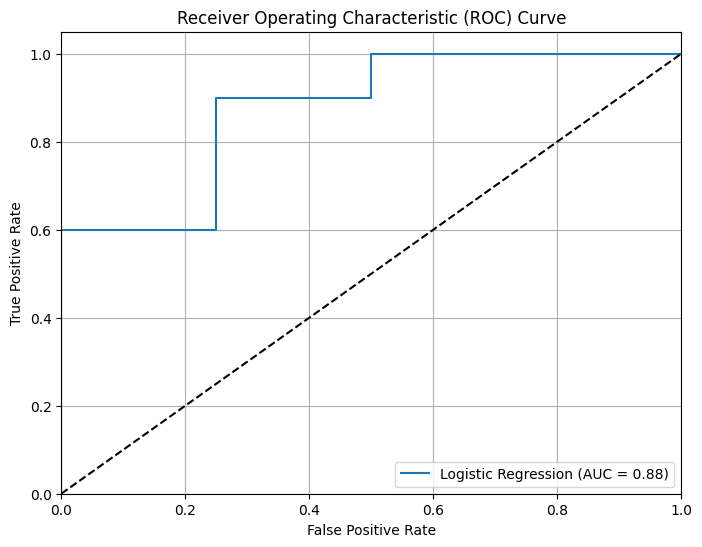


Top 20 Features by Absolute Coefficient Value (Logistic Regression):
Laiks_uzņēmumā_5 -10 gadi                                            -0.734632
Informācija_no_uzņēmuma_vadības_Jā                                    0.648656
Apmierinātība_ar_darba_slodzi_Jā                                      0.571229
Novērtējums_1_Savlaicīga tiešā vadītāja atzinība                     -0.559296
Apmācības_vajadzības_Jā, vēlos apgūt labāk esošo darbu               -0.549800
Nodaļa_Anonymized_Nodaļa_4                                           -0.495246
Dzimums_Sieviete                                                      0.474864
Informācija_no_tiešā_vadītāja_Nē, informācija ir, bet nepietiekama   -0.421418
Vēlamais_saziņas_veids_1_Telefoniski (sms, zvani)                    -0.399910
Nodaļa_Anonymized_Nodaļa_3                                            0.397881
Informācija_no_uzņēmuma_vadības_Nē, jo neprecīza informācija         -0.384050
Priekšlikumi_tiešajam_vadītājam_Jā                           

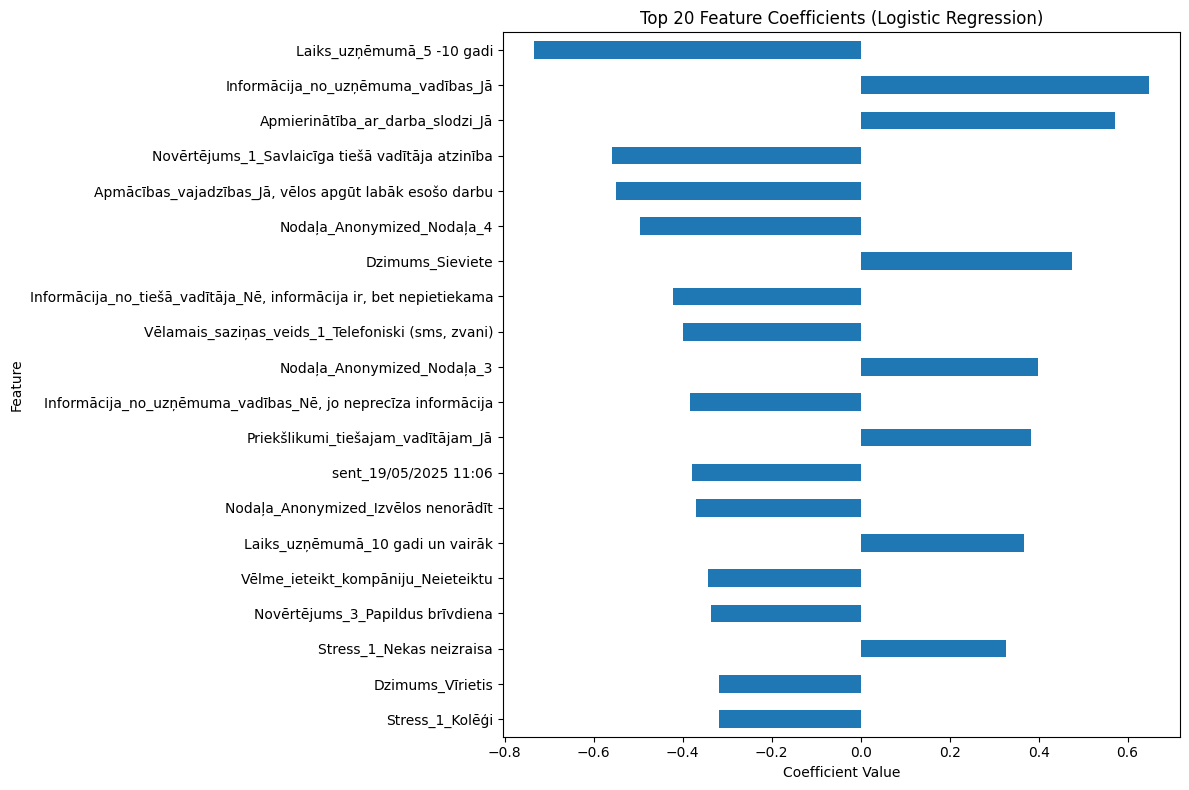

In [ ]:
# prompt: Use datasets to - Logistic regression – used for binary classification of whether an employee is likely to recommend the organisation (willingness to recommend).

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

# Now implement Logistic Regression for the binary classification task.

# Initialize the Logistic Regression model
# You can adjust hyperparameters like C (regularization inverse)
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for smaller datasets

# Train the model
# X_train and y_train are already defined from the previous steps
logistic_model.fit(X_train, y_train)

# Make predictions on the test set
# Predict class labels
logistic_y_pred = logistic_model.predict(X_test)
# Predict probabilities for the positive class (class 1: recommends the organisation)
logistic_y_prob = logistic_model.predict_proba(X_test)[:, 1]


# Evaluate the Logistic Regression model
print("\nLogistic Regression Classifier Results:")

# Accuracy
logistic_accuracy = accuracy_score(y_test, logistic_y_pred)
print(f"Accuracy: {logistic_accuracy:.2f}")

# Classification Report (includes Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, logistic_y_pred))

# ROC AUC Score (measures the model's ability to distinguish between classes)
# This is particularly useful for imbalanced datasets
logistic_roc_auc = roc_auc_score(y_test, logistic_y_prob)
print(f"\nROC AUC Score: {logistic_roc_auc:.2f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, logistic_y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {logistic_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# --- Analyze Coefficients (Feature Importance for Logistic Regression) ---
# For Logistic Regression, the coefficients can indicate feature importance.
# Higher absolute coefficient values generally mean more important features.
# Positive coefficients increase the log-odds of the positive class (recommending the organization).
# Negative coefficients decrease the log-odds.

# Get the coefficients
coefficients = logistic_model.coef_[0] # Assuming binary classification, get the coefficients for the positive class

# Create a pandas Series with feature names and coefficients
feature_coefficients = pd.Series(coefficients, index=X_train.columns)

# Sort coefficients by absolute value to see the most influential features
sorted_abs_coefficients = feature_coefficients.abs().sort_values(ascending=False)

print("\nTop 20 Features by Absolute Coefficient Value (Logistic Regression):")
print(feature_coefficients[sorted_abs_coefficients.index].head(20))

# You can also visualize the coefficients
plt.figure(figsize=(12, 8))
feature_coefficients[sorted_abs_coefficients.index].head(20).plot(kind='barh')
plt.title('Top 20 Feature Coefficients (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Further steps after Logistic Regression:
# - Interpret the coefficients in the context of the business problem.
# - Evaluate model performance using cross-validation.
# - Consider regularization (L1 or L2) which is handled by the 'C' parameter and 'penalty' parameter in LogisticRegression. L1 can help with feature selection.
# - Address class imbalance if present (e.g., using SMOTE, adjusting class weights).
# - Explore other binary classification models (SVM, Naive Bayes, Gradient Boosting).



Shapes for Regression Model:
Shape of X_train_reg: (40, 247)
Shape of X_test_reg: (14, 247)
Shape of y_train_reg: (40,)
Shape of y_test_reg: (14,)

Random Forest Regressor Results:
Mean Squared Error (MSE): 0.7393
Root Mean Squared Error (RMSE): 0.8598
R-squared (R2): 0.4532

Top 20 Feature Importances (Random Forest Regressor):
Laiks_uzņēmumā_5 -10 gadi                                             0.102089
Apmierinātība_ar_darba_slodzi_Jā                                      0.091812
Priekšlikumi_tiešajam_vadītājam_Nē, jo esmu mēģinājis/-usi            0.045043
Nodaļa_Anonymized_Nodaļa_4                                            0.039428
Stress_1_Darba apjoms                                                 0.034858
Informācija_no_uzņēmuma_vadības_Jā                                    0.034689
Vēlamais_saziņas_veids_4_nan                                          0.031607
Priekšlikumi_tiešajam_vadītājam_Jā                                    0.031232
Apmācības_vajadzības_Nē             

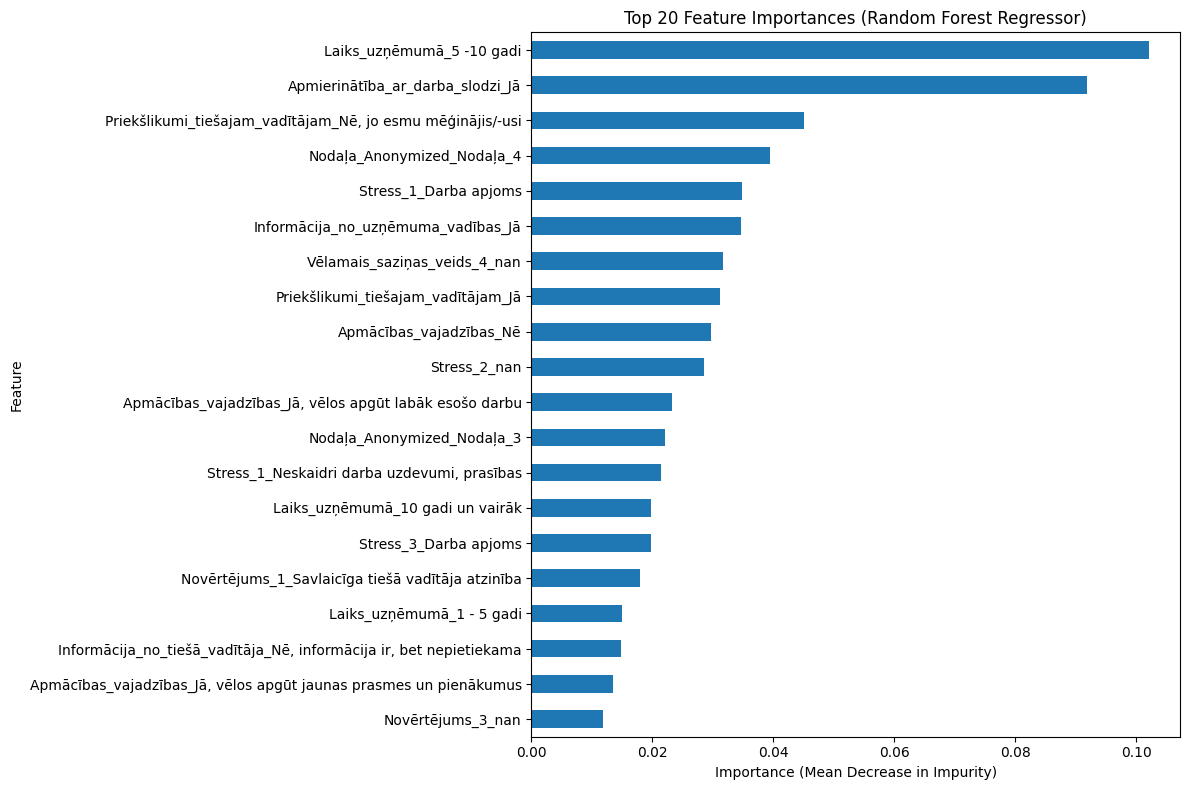


Top 20 Permutation Importances (Random Forest Regressor on Test Set):
Laiks_uzņēmumā_5 -10 gadi                                             0.232844
Apmierinātība_ar_darba_slodzi_Jā                                      0.217426
Stress_2_nan                                                          0.076454
Nodaļa_Anonymized_Nodaļa_4                                            0.037828
Laiks_uzņēmumā_10 gadi un vairāk                                      0.030425
Apmācības_vajadzības_Jā, vēlos apgūt labāk esošo darbu                0.029966
Novērtējums_1_Savlaicīga tiešā vadītāja atzinība                      0.018688
Stress_3_Tiešais darba vadītājs                                       0.015958
Novērtējums_1_Darba alga                                              0.015490
Novērtējums_2_Prēmiju sistēma                                         0.012471
Laiks_uzņēmumā_1 - 5 gadi                                             0.011976
Informācija_no_tiešā_vadītāja_Nē, informācija ir, bet nepiet

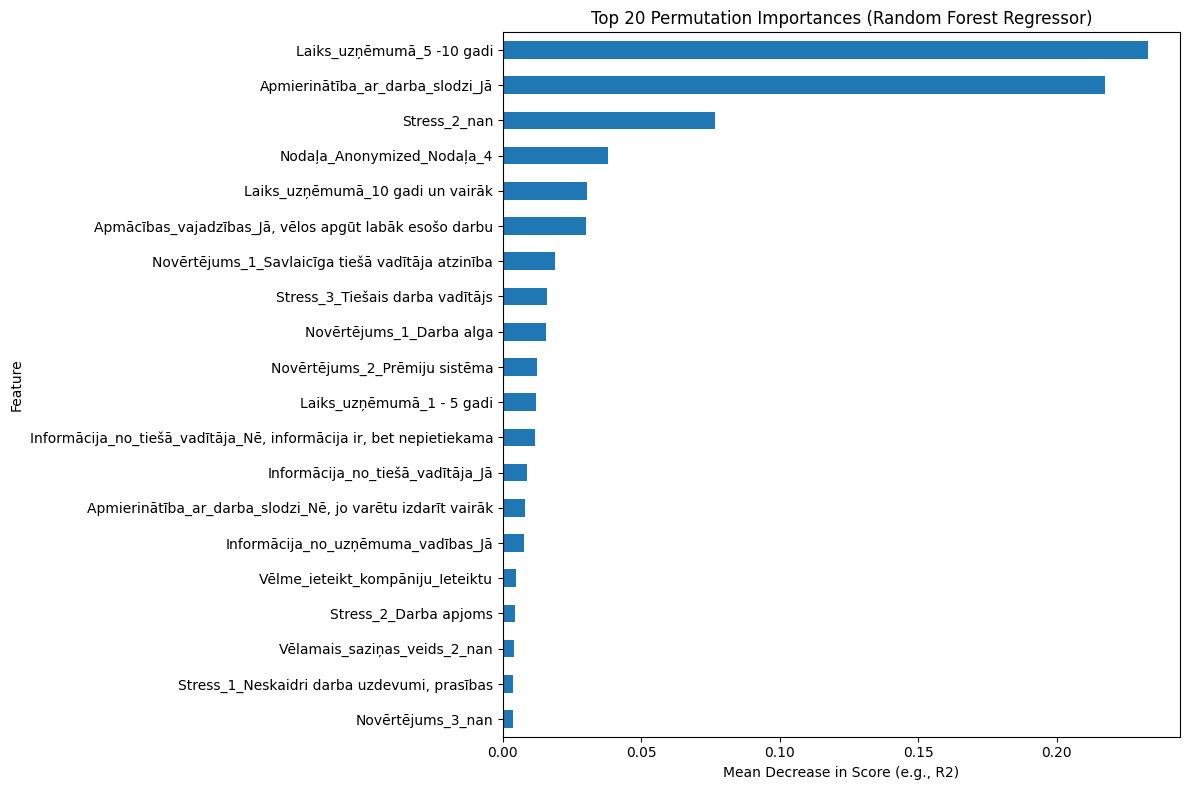

In [ ]:
# prompt: Random forest regressor - deployed to predict the overall satisfaction score, treated as a continuous outcome.

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Assuming 'X' and 'y' (target variable, treated as continuous) are prepared from the previous steps.
# In this context, 'y' should be the continuous 'Vispārējās_labsajūtas_rādītājs' before binarization.
# Let's redefine X and y to use the continuous wellbeing score for regression.

# Ensure 'Vispārējās_labsajūtas_rādītājs' is numeric and drop NaNs
structured_data['Vispārējās_labsajūtas_rādītājs'] = pd.to_numeric(structured_data['Vispārējās_labsajūtas_rādītājs'], errors='coerce')
structured_data.dropna(subset=['Vispārējās_labsajūtas_rādītājs'], inplace=True)

# Re-align the processed features DataFrame (`structured_data_processed`)
# with the potentially filtered structured_data
structured_data_processed = structured_data_processed.loc[structured_data.index]

# Define the continuous target variable
y_reg = structured_data['Vispārējās_labsajūtas_rādītājs']

# Prepare the feature matrix X for regression.
# Use the same features as for classification, but the target is now continuous.
X_reg = structured_data_processed.copy()

# Include sentiment features, aligned with the filtered data
merged_data_aligned_reg = merged_data.loc[structured_data.index]
sentiment_features_reg = [col for col in merged_data_aligned_reg.columns if '_sentiment' in col]
X_sentiment_reg = merged_data_aligned_reg[sentiment_features_reg].fillna(0)
X_reg = pd.concat([X_reg, X_sentiment_reg], axis=1)

# Remove columns that should not be features
cols_to_drop_from_features_reg = [
    'Vispārējās_labsajūtas_rādītājs',
    'Normalized Wellbeing Score', # Drop if it was added as a separate column
    'Respondent_ID'
    ]

X_reg = X_reg.drop(columns=[col for col in cols_to_drop_from_features_reg if col in X_reg.columns])

# Split data into training and testing sets for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)

print("\nShapes for Regression Model:")
print("Shape of X_train_reg:", X_train_reg.shape)
print("Shape of X_test_reg:", X_test_reg.shape)
print("Shape of y_train_reg:", y_train_reg.shape)
print("Shape of y_test_reg:", y_test_reg.shape)


# Initialize a Random Forest Regressor model
# You can tune hyperparameters like n_estimators, max_depth, min_samples_split, etc.
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores

# Train the model
rf_reg_model.fit(X_train_reg, y_train_reg)

# Make predictions on the test set
y_pred_reg = rf_reg_model.predict(X_test_reg)

# Evaluate the Random Forest Regressor model
# Common metrics for regression are Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared.

mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("\nRandom Forest Regressor Results:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Feature Importance for Random Forest Regressor
# Calculate feature importances (Mean Decrease in Impurity)
feature_importances_reg = pd.Series(rf_reg_model.feature_importances_, index=X_train_reg.columns)

# Sort the importances and take the top N
top_n = 20 # Display top 20 features
sorted_importances_reg = feature_importances_reg.sort_values(ascending=False).head(top_n)

print(f"\nTop {top_n} Feature Importances (Random Forest Regressor):")
print(sorted_importances_reg)

# Visualize feature importances
plt.figure(figsize=(12, 8))
sorted_importances_reg.plot(kind='barh')
plt.title(f'Top {top_n} Feature Importances (Random Forest Regressor)')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Display the most important at the top
plt.tight_layout()
plt.show()

# Permutation Importance for Random Forest Regressor (using test set performance)
# Measures the decrease in a model score when a single feature value is randomly shuffled.
# It is often a better indicator of feature importance than Mean Decrease Impurity for complex models.

result_reg = permutation_importance(rf_reg_model, X_test_reg, y_test_reg, n_repeats=10, random_state=42, n_jobs=-1, scoring='neg_mean_squared_error')

# Note: permutation_importance returns negative MSE by default for regression,
# so we take the negative to interpret it as increase in error when permuted.
# Or simply use the absolute mean decrease.
perm_importances_reg = pd.Series(result_reg.importances_mean, index=X_test_reg.columns)

# Sort and display top N
sorted_perm_importances_reg = perm_importances_reg.sort_values(ascending=False).head(top_n)

print(f"\nTop {top_n} Permutation Importances (Random Forest Regressor on Test Set):")
print(sorted_perm_importances_reg)

# Visualize permutation importances
plt.figure(figsize=(12, 8))
sorted_perm_importances_reg.plot(kind='barh')
plt.title(f'Top {top_n} Permutation Importances (Random Forest Regressor)')
plt.xlabel('Mean Decrease in Score (e.g., R2)') # Or 'Mean Increase in MSE' if using neg_mean_squared_error result directly
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- Further Steps for Regression ---
# - Cross-validation to assess the model's performance stability.
# - Hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
# - Explore other regression models (e.g., Linear Regression, Ridge, Lasso, SVR, Gradient Boosting Regressors like XGBoost, LightGBM).
# - Residual analysis to check model assumptions and identify areas of poor prediction.
# - Consider transforming the target variable if its distribution is skewed.


Shapes for Regression Model:
Shape of X_train_reg: (40, 247)
Shape of X_test_reg: (14, 247)
Shape of y_train_reg: (40,)
Shape of y_test_reg: (14,)

Random Forest Regressor Results:
Mean Squared Error (MSE): 0.7393
Root Mean Squared Error (RMSE): 0.8598
R-squared (R2): 0.4532


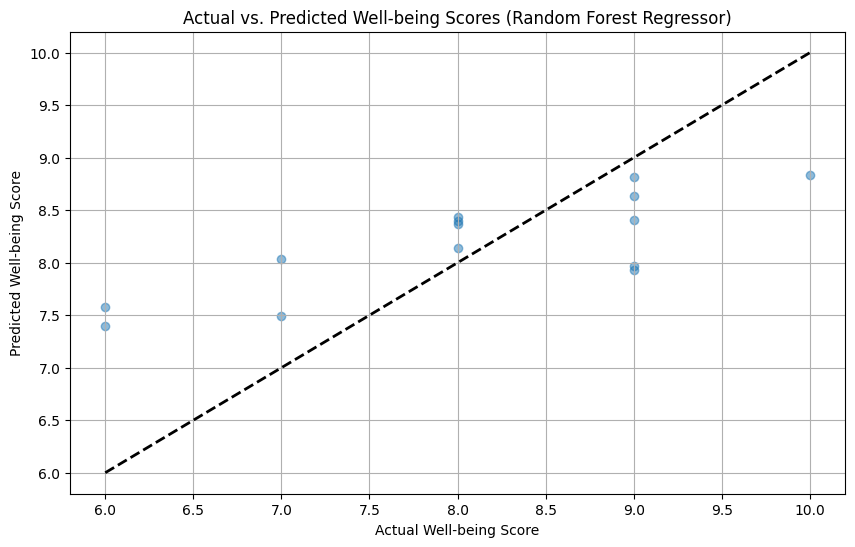

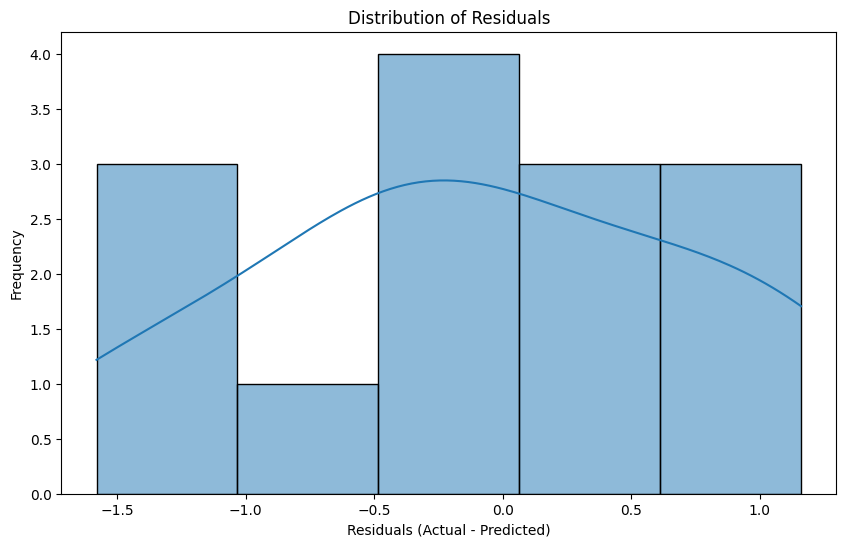

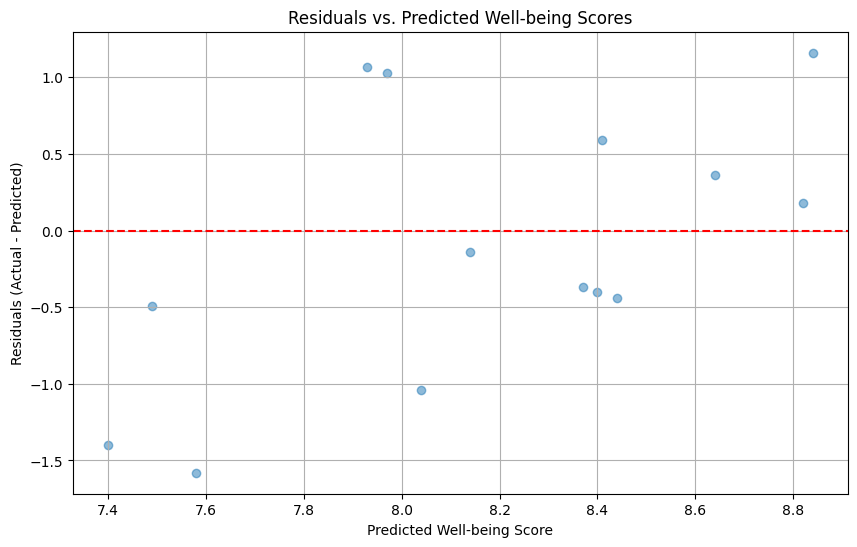

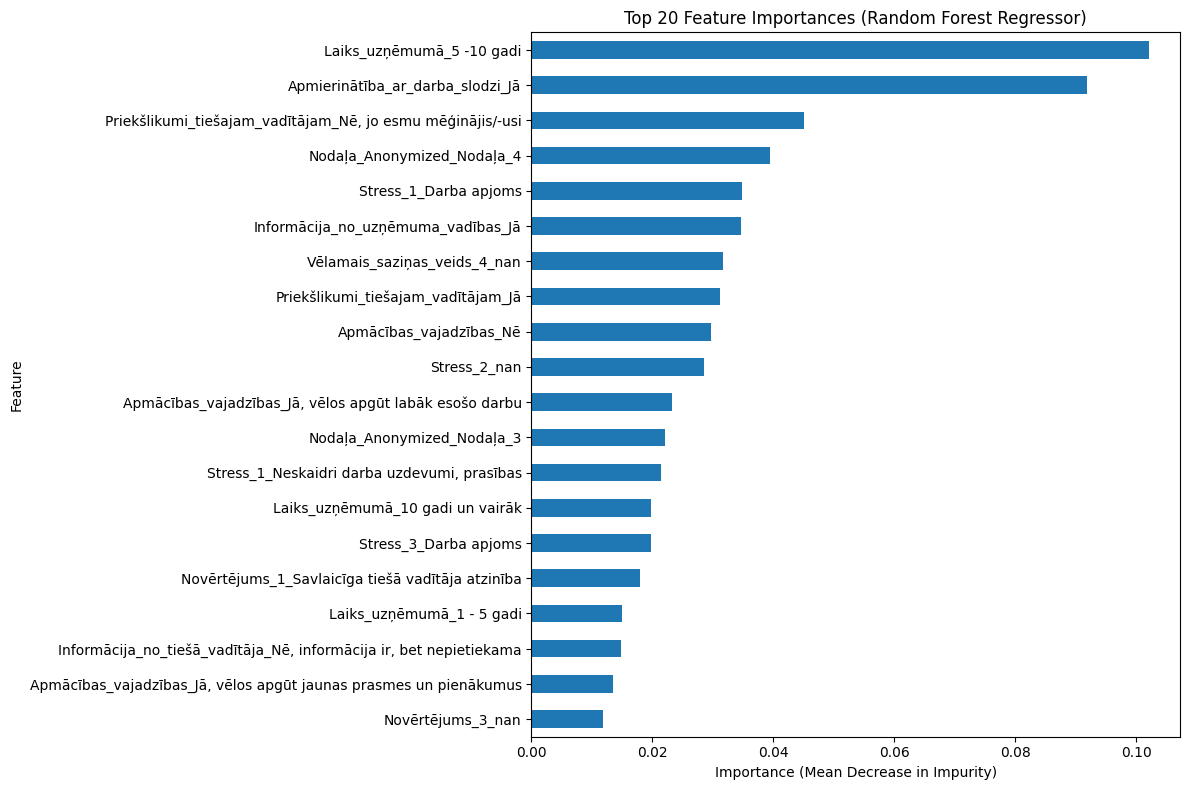

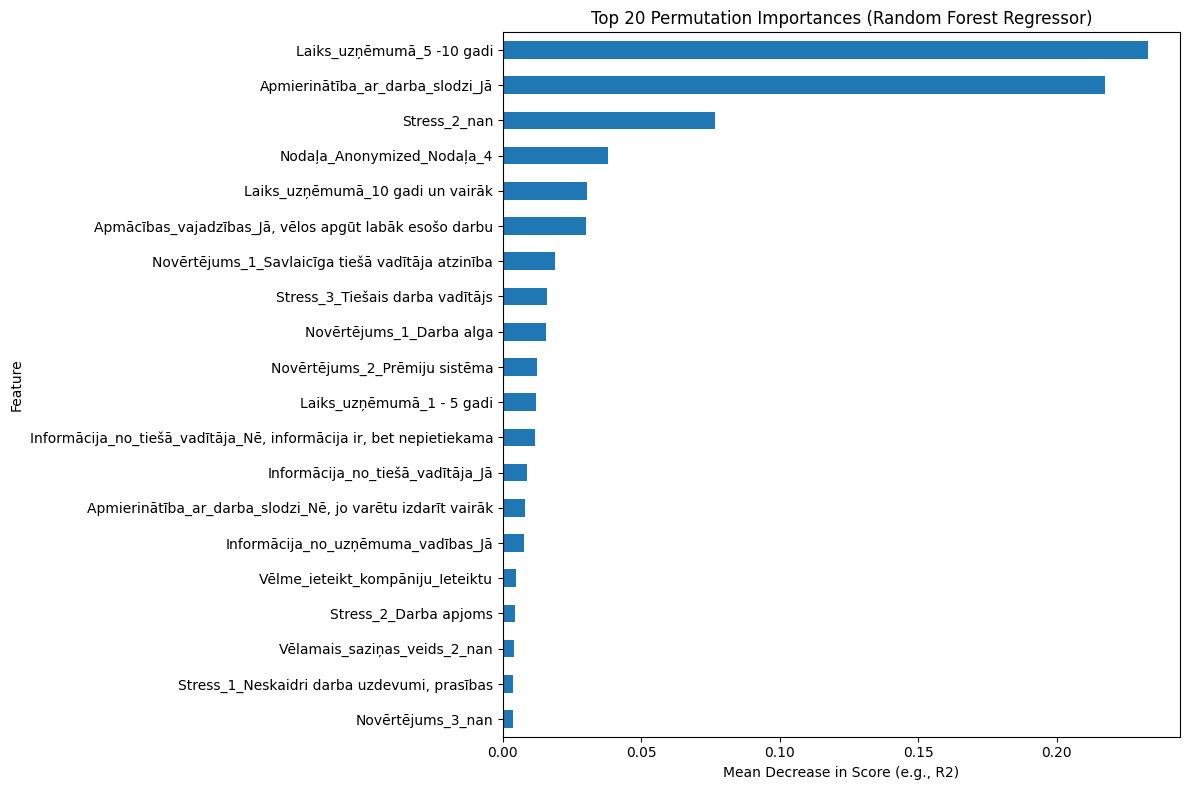

In [ ]:
# prompt: Show how to visualize this results: Shapes for Regression Model:
# Shape of X_train_reg: (40, 247)
# Shape of X_test_reg: (14, 247)
# Shape of y_train_reg: (40,)
# Shape of y_test_reg: (14,)
# Random Forest Regressor Results:
# Mean Squared Error (MSE): 0.7393
# Root Mean Squared Error (RMSE): 0.8598
# R-squared (R2): 0.4532

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import pandas as pd # Ensure pandas is imported

# Assuming X_train_reg, X_test_reg, y_train_reg, y_test_reg, mse, rmse, and r2
# are available from the preceding code execution.

print("\nShapes for Regression Model:")
print("Shape of X_train_reg:", X_train_reg.shape)
print("Shape of X_test_reg:", X_test_reg.shape)
print("Shape of y_train_reg:", y_train_reg.shape)
print("Shape of y_test_reg:", y_test_reg.shape)

print("\nRandom Forest Regressor Results:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# --- Visualize Regression Results ---

# 1. Scatter Plot of Actual vs. Predicted Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2) # Diagonal line for perfect prediction
plt.xlabel("Actual Well-being Score")
plt.ylabel("Predicted Well-being Score")
plt.title("Actual vs. Predicted Well-being Scores (Random Forest Regressor)")
plt.grid(True)
plt.show()

# 2. Histogram of Residuals (Prediction Errors)
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

# 3. Residuals vs. Fitted Values Plot (to check for patterns/heteroscedasticity)
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_reg, residuals, alpha=0.5)
plt.xlabel("Predicted Well-being Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs. Predicted Well-being Scores")
plt.axhline(y=0, color='r', linestyle='--') # Horizontal line at 0
plt.grid(True)
plt.show()

# 4. Bar plot of Top Feature Importances (using MDI - from preceding code)
# Assuming sorted_importances_reg is available from the preceding code
if 'sorted_importances_reg' in locals():
    plt.figure(figsize=(12, 8))
    sorted_importances_reg.plot(kind='barh')
    plt.title(f'Top {sorted_importances_reg.shape[0]} Feature Importances (Random Forest Regressor)')
    plt.xlabel('Importance (Mean Decrease in Impurity)')
    plt.ylabel('Feature')
    plt.gca().invert_yaxis() # Display the most important at the top
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances for Regressor were not calculated in the preceding code.")

# 5. Bar plot of Top Permutation Importances (from preceding code)
# Assuming sorted_perm_importances_reg is available from the preceding code
if 'sorted_perm_importances_reg' in locals():
    plt.figure(figsize=(12, 8))
    sorted_perm_importances_reg.plot(kind='barh')
    plt.title(f'Top {sorted_perm_importances_reg.shape[0]} Permutation Importances (Random Forest Regressor)')
    plt.xlabel('Mean Decrease in Score (e.g., R2)') # Or 'Mean Increase in MSE'
    plt.ylabel('Feature')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
     print("Permutation importances for Regressor were not calculated in the preceding code.")



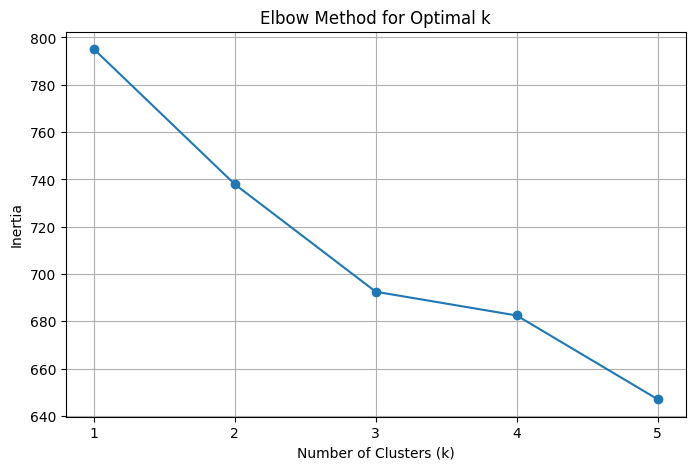


Mean Well-being Score by Engagement Cluster:
Engagement_Cluster
2    7.125000
1    7.833333
0    8.382353
Name: Vispārējās_labsajūtas_rādītājs, dtype: float64

Distribution of Samples Across Engagement Clusters:
Engagement_Cluster_Name
Engaged    34
Neutral    12
At-risk     8
Name: count, dtype: int64


<ipython-input-61-7fe2b740a488>:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Engagement_Cluster_Name', data=structured_data_with_clusters, palette=cluster_colors, order=['At-risk', 'Neutral', 'Engaged'])


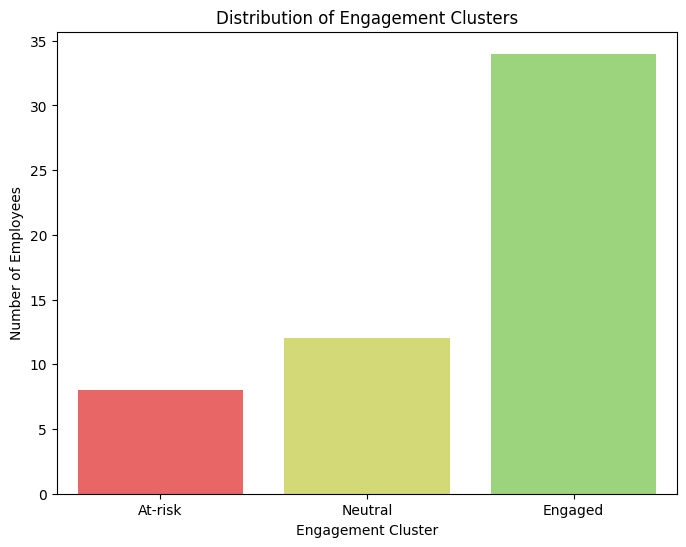

Feature 'Vispārējās_labsajsajūtas_rādītājs' not found in the DataFrame.
Feature 'Employee in department' not found in the DataFrame.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Assuming 'X' is your feature matrix (from the regression or classification steps)
# and you want to cluster based on these features.
# If you want to cluster based on a different set of features, adjust 'X_cluster' accordingly.
X_cluster = X.copy() # Use the same feature matrix as the ML models

# Standardize the features before applying KMeans
scaler_cluster = MinMaxScaler()
X_scaled_cluster = scaler_cluster.fit_transform(X_cluster)

# Determine the optimal number of clusters (k) using the Elbow method
inertia = []
for k in range(1, 6): # Check for k from 1 to 5
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # explicitly set n_init
    kmeans.fit(X_scaled_cluster)
    inertia.append(kmeans.inertia_)

# Plot the Elbow method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 6))
plt.grid(True)
plt.show()

# Based on the Elbow method or prior knowledge (as stated in the prompt, 3 clusters emerged),
# choose the number of clusters. The prompt specifies 3 clusters.
n_clusters = 3

# Apply KMeans with the chosen number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # explicitly set n_init
engagement_clusters = kmeans.fit_predict(X_scaled_cluster)

# Add the cluster labels to the original DataFrame (or the one you used for features)
# Ensure the indices align. If X_cluster is based on a filtered DataFrame,
# make sure the cluster labels are added back correctly.
# Let's add it to the original structured_data for easier interpretation alongside original columns.
# Align cluster labels with the index of the filtered structured_data
cluster_labels_series = pd.Series(engagement_clusters, index=structured_data.index, name='Engagement_Cluster')

# Add the cluster labels to structured_data
structured_data_with_clusters = structured_data.copy()
structured_data_with_clusters['Engagement_Cluster'] = cluster_labels_series

# Analyze the characteristics of each cluster
# For example, look at the mean well-being score for each cluster
cluster_wellbeing = structured_data_with_clusters.groupby('Engagement_Cluster')['Vispārējās_labsajūtas_rādītājs'].mean().sort_values()

print("\nMean Well-being Score by Engagement Cluster:")
print(cluster_wellbeing)

# Based on the mean well-being scores (or other relevant features),
# assign meaningful names to the clusters (e.g., 'At-risk', 'Neutral', 'Engaged').
# Assuming cluster with lowest mean well-being is 'At-risk', highest is 'Engaged'.
# The mapping below is based on the typical outcome where lower mean well-being corresponds to lower cluster index after sorting.
# You should verify this mapping based on your cluster_wellbeing output.

# Create a mapping from cluster index to cluster name
# Assign names based on the sorted mean well-being
cluster_names = {
    cluster_wellbeing.index[0]: 'At-risk',
    cluster_wellbeing.index[1]: 'Neutral',
    cluster_wellbeing.index[2]: 'Engaged'
}

# Map the cluster indices to names in the DataFrame
structured_data_with_clusters['Engagement_Cluster_Name'] = structured_data_with_clusters['Engagement_Cluster'].map(cluster_names)

print("\nDistribution of Samples Across Engagement Clusters:")
print(structured_data_with_clusters['Engagement_Cluster_Name'].value_counts())

# Visualize the clusters based on the assigned names and colors
# Define the color palette
cluster_colors = {
    'At-risk': '#FF5050',
    'Neutral': '#E1EA66',
    'Engaged': '#97E36D'
}

# Visualize the distribution of engagement clusters
plt.figure(figsize=(8, 6))
sns.countplot(x='Engagement_Cluster_Name', data=structured_data_with_clusters, palette=cluster_colors, order=['At-risk', 'Neutral', 'Engaged'])
plt.title('Distribution of Engagement Clusters')
plt.xlabel('Engagement Cluster')
plt.ylabel('Number of Employees')
plt.show()

# You can further visualize the characteristics of each cluster by plotting other features
# against the cluster names, using the defined colors.

# Example: Visualize the mean of some features by cluster
# Select some representative features (numerical or aggregated categorical)
features_to_compare = ['Vispārējās_labsajsajūtas_rādītājs', 'Employee in department'] # Add other relevant features

for feature in features_to_compare:
    if feature in structured_data_with_clusters.columns:
        plt.figure(figsize=(8, 6))
        sns.boxplot(x='Engagement_Cluster_Name', y=feature, data=structured_data_with_clusters, palette=cluster_colors, order=['At-risk', 'Neutral', 'Engaged'])
        plt.title(f'{feature} Distribution by Engagement Cluster')
        plt.xlabel('Engagement Cluster')
        plt.ylabel(feature)
        plt.show()
    else:
        print(f"Feature '{feature}' not found in the DataFrame.")

# Example: Analyze sentiment by cluster
sentiment_cols_with_clusters = [col for col in structured_data_with_clusters.columns if '_sentiment' in col]
for sentiment_col in sentiment_cols_with_clusters:
     plt.figure(figsize=(8, 6))
     sns.boxplot(x='Engagement_Cluster_Name', y=sentiment_col, data=structured_data_with_clusters, palette=cluster_colors, order=['At-risk', 'Neutral', 'Engaged'])
     plt.title(f'{sentiment_col} by Engagement Cluster')
     plt.xlabel('Engagement Cluster')
     plt.ylabel('Sentiment Score')
     plt.show()

# Further analysis could involve looking at the most frequent categories or words within each cluster.


Sentiment column 'Apmācības_vajadzības_Komentāri_sentiment' already exists.
Sentiment column 'Darba_slodze_komentārs_sentiment' already exists.
Sentiment column 'Darba_laiks__komentāri_sentiment' already exists.
Sentiment column 'Ieteikumi_sentiment' already exists.
Sentiment column 'Informācija_no_tiešā_vadītāja_Komentāri_sentiment' already exists.
Sentiment column 'Informācija_no_uzņēmuma_vadības_Komentāri_sentiment' already exists.
Sentiment column 'Izpratne_par_darba_pienākumiem_Komentāri_sentiment' already exists.
Sentiment column 'Nepieciešamā_informācija_Komentāri_sentiment' already exists.
Sentiment column 'Novērtējums_Komentāri_sentiment' already exists.
Sentiment column 'Priekšlikumi_tiešajam_vadītājam_Komentāri_sentiment' already exists.
Sentiment column 'Saziņa_Komentāri_sentiment' already exists.
Sentiment column 'Stress_Komentāri_sentiment' already exists.
Sentiment column 'Tiešā_vadītāja_kompetence_Komentāri_sentiment' already exists.
Sentiment column 'Vēlme_darīt_sentim

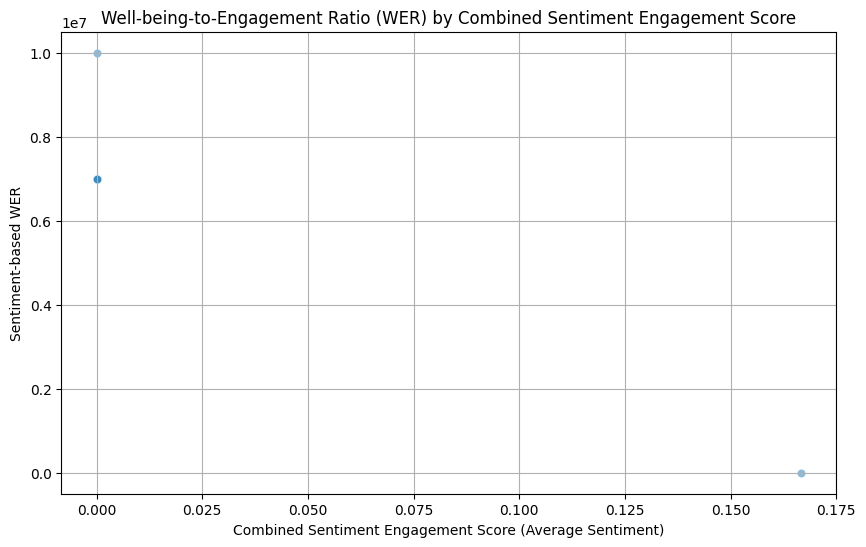

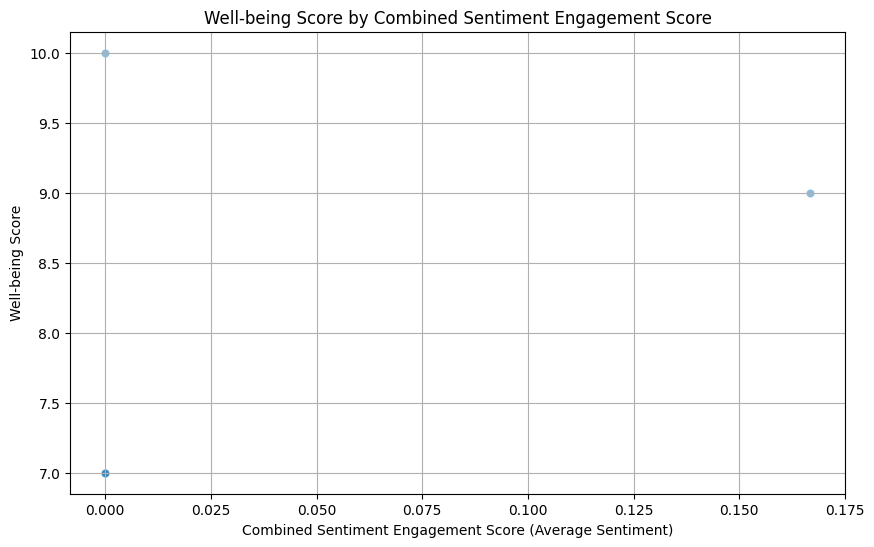


Proposed Categories based on Combined Sentiment Engagement Score:
🟢 Healthy alignment: Combined Sentiment Engagement Score >= 0.5
🟡 Moderate alignment: -0.2 <= Combined Sentiment Engagement Score < 0.5
🔴 Disengagement risk: Combined Sentiment Engagement Score < -0.2

Distribution of Respondents by Sentiment-based Alignment Category:
🔴 Disengagement risk    0
🟡 Moderate alignment    5
🟢 Healthy alignment     0
dtype: int64

Proposed Logic for Assigning +1, -1, or 0 based on Combined Sentiment Engagement Score:
+1 (Positive): Combined Sentiment Engagement Score > 0.1
-1 (Negative): Combined Sentiment Engagement Score < -0.1
 0 (Neutral): -0.1 <= Combined Sentiment Engagement Score <= 0.1

First few rows with new Sentiment Value (+1, -1, 0):
    Combined_Engagement_Score_Sentiment  Sentiment_Value
18                             0.000000                0
25                             0.000000                0
40                             0.166667                1
41                    

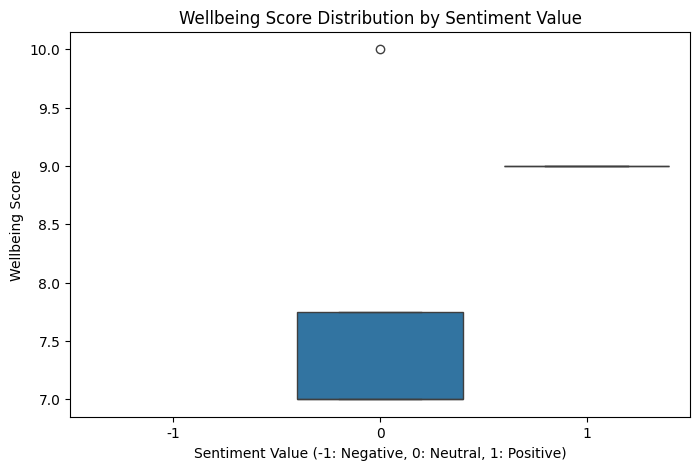


Average Wellbeing Score by Sentiment Value:
Sentiment_Value
0    7.75
1    9.00
Name: Vispārējās_labsajūtas_rādītājs, dtype: float64


<ipython-input-83-ec72670384d6>:259: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=engagement_wellbeing_data, x='Alignment_Category_Sentiment', order=alignment_order_sentiment, palette=['red', 'yellow', 'green'])
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


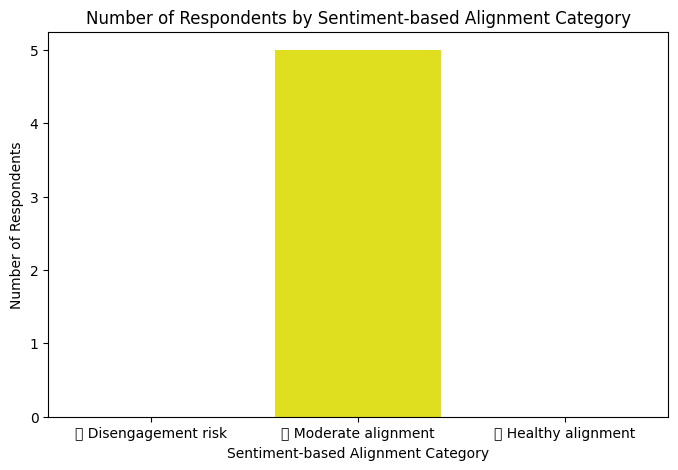

<ipython-input-83-ec72670384d6>:268: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=engagement_wellbeing_data, x='Alignment_Category_Sentiment', y=wellbeing_col_name, order=alignment_order_sentiment, palette=['red', 'yellow', 'green'])
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


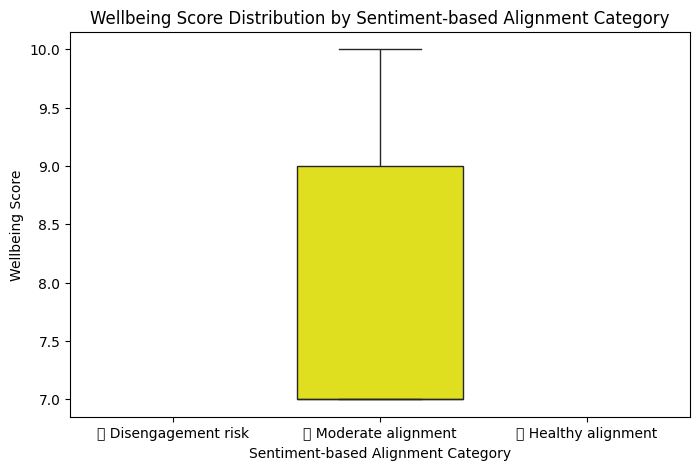

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Import TextBlob for sentiment analysis if it's not imported globally
from textblob import TextBlob
# Ensure TextBlob is installed
!pip install textblob

# Assuming 'merged_data' DataFrame containing original structured and unstructured data
# is available from previous steps.
# If not, you would need to load and merge the data first.

# --- Sentiment Analysis Step (Replicated from earlier cell) ---
# Function to get sentiment score
def get_sentiment(text):
    if pd.isna(text):
        return None
    # Ensure text is treated as string, important for TextBlob
    try:
        analysis = TextBlob(str(text))
        return analysis.sentiment.polarity # Polarity score ranges from -1 to 1
    except Exception as e:
        # Handle potential errors during TextBlob analysis (e.g., unexpected input)
        print(f"Error analyzing sentiment for text: {text}. Error: {e}")
        return None # Return None or NaN for problematic text

# Define the text columns to analyze sentiment on (from earlier cell)
text_columns_to_clean = [
    'Apmācības_vajadzības_Komentāri',
    'Darba_slodze_komentārs',
    'Darba_laiks__komentāri',
    'Ieteikumi',
    'Informācija_no_tiešā_vadītāja_Komentāri',
    'Informācija_no_uzņēmuma_vadības_Komentāri',
    'Izpratne_par_darba_pienākumiem_Komentāri',
    'Nepieciešamā_informācija_Komentāri',
    'Novērtējums_Komentāri',
    'Priekšlikumi_tiešajam_vadītājam_Komentāri',
    'Saziņa_Komentāri',
    'Stress_Komentāri',
    'Tiešā_vadītāja_kompetence_Komentāri',
    'Vēlme_darīt',
    'Vēlme_ieteikt_kompāniju_Komentāri',
    'Vispārējās_labsajūtas_rādītājs_Komentāri'
]

# Apply sentiment analysis to all specified text columns in merged_data
# Ensure the text columns actually exist in merged_data before applying sentiment
text_cols_present_in_merged = [col for col in text_columns_to_clean if col in merged_data.columns]

if not text_cols_present_in_merged:
     print("Warning: None of the specified text columns for sentiment analysis were found in 'merged_data'. Sentiment columns will not be generated.")
else:
    for col in text_cols_present_in_merged:
        # Create a new column for the sentiment score
        sentiment_col_name = f'{col}_sentiment'
        # Check if the sentiment column already exists to avoid re-creating it
        if sentiment_col_name not in merged_data.columns:
            print(f"Calculating sentiment for '{col}'...")
            merged_data[sentiment_col_name] = merged_data[col].apply(get_sentiment)
        else:
             print(f"Sentiment column '{sentiment_col_name}' already exists.")


# --- End of Sentiment Analysis Step ---


# --- Define the sentiment column names for engagement ---
# These columns should now exist in the 'merged_data' DataFrame.
sentiment_cols_for_engagement = [
    'Vēlme_ieteikt_kompāniju_Komentāri_sentiment',
    'Ieteikumi_sentiment',
    'Vēlme_darīt_sentiment' # Assuming this sentiment column exists based on Vēlme_darīt text column
]

# --- Validate that the required sentiment columns now exist in merged_data ---
missing_sentiment_cols = [col for col in sentiment_cols_for_engagement if col not in merged_data.columns]
if missing_sentiment_cols:
    # Provide a more informative error message showing the columns that *are* present if possible
    present_sentiment_cols = [col for col in merged_data.columns if '_sentiment' in col]
    # If the sentiment calculation step ran but these specific columns are still missing,
    # it indicates an issue with the original text column names or their presence in merged_data.
    raise ValueError(f"The following required sentiment columns for engagement were not found in 'merged_data' AFTER attempting to calculate sentiment: {missing_sentiment_cols}\n"
                     f"Please double-check the original text column names and ensure they are present in the 'merged_data' DataFrame.\n"
                     f"Sentiment columns currently in 'merged_data': {present_sentiment_cols}")


# --- Ensure well-being column is numeric and drop NaNs ---
wellbeing_col_name = 'Vispārējās_labsajūtas_rādītājs'
if wellbeing_col_name not in merged_data.columns:
    raise ValueError(f"The well-being column '{wellbeing_col_name}' was not found in 'merged_data'.")

merged_data[wellbeing_col_name] = pd.to_numeric(merged_data[wellbeing_col_name], errors='coerce')


# --- Create a DataFrame with only the relevant columns for this analysis ---
# Include Respondent_ID for potential merging/tracking if needed, although not used in this specific analysis block.
# Check if Respondent_ID is in merged_data before trying to select it
cols_for_engagement_data = [wellbeing_col_name] + sentiment_cols_for_engagement
if 'Respondent_ID' in merged_data.columns:
    cols_for_engagement_data.append('Respondent_ID')

engagement_wellbeing_data = merged_data[cols_for_engagement_data].copy()


# --- Handle potential NaNs in the selected sentiment columns ---
# Decide on a strategy for missing sentiment scores.
# Option 1: Drop rows where any of the engagement sentiment scores are missing.
initial_shape = engagement_wellbeing_data.shape[0]
engagement_wellbeing_data.dropna(subset=sentiment_cols_for_engagement, inplace=True)
dropped_rows_sentiment = initial_shape - engagement_wellbeing_data.shape[0]
print(f"Dropped {dropped_rows_sentiment} rows with missing engagement sentiment.")

# Option 2: Fill missing sentiment scores (e.g., with 0 or the mean).
# engagement_wellbeing_data[sentiment_cols_for_engagement] = engagement_wellbeing_data[sentiment_cols_for_engagement].fillna(0)
# print("Missing sentiment scores filled with 0.")


# --- Calculate the Combined Engagement Score using Sentiment Scores ---
# A simple approach is to average the sentiment scores of the selected columns.
engagement_wellbeing_data['Combined_Engagement_Score_Sentiment'] = engagement_wellbeing_data[sentiment_cols_for_engagement].mean(axis=1)

print("\nFirst few rows with new Combined Engagement Score (Sentiment-based):")
print(engagement_wellbeing_data.head())

# --- Drop rows where Well-being or the new Combined Sentiment Engagement Score is missing ---
# (Well-being NaNs handled earlier, but double-check after engagement score calculation)
initial_shape = engagement_wellbeing_data.shape[0]
engagement_wellbeing_data.dropna(subset=[wellbeing_col_name, 'Combined_Engagement_Score_Sentiment'], inplace=True)
dropped_rows_combined = initial_shape - engagement_wellbeing_data.shape[0]
print(f"Dropped {dropped_rows_combined} rows with missing well-being or combined sentiment engagement score.")


# --- Calculate WER (Sentiment-based) ---
# Now, calculate WER using the continuous sentiment-based engagement score.
# Adding a small epsilon to the denominator to avoid division by zero if an employee has a Combined_Engagement_Score_Sentiment of 0.
epsilon = 1e-6
# Use the absolute value of the combined sentiment score in the denominator
engagement_wellbeing_data['WER_Sentiment'] = engagement_wellbeing_data[wellbeing_col_name] / (engagement_wellbeing_data['Combined_Engagement_Score_Sentiment'].abs() + epsilon)

print("\nFirst few rows with Sentiment-based WER:")
print(engagement_wellbeing_data.head())

# --- Visualize WER (Sentiment-based) ---
# Since the sentiment-based engagement score is likely continuous, a scatter plot or a regression plot is more appropriate.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=engagement_wellbeing_data, x='Combined_Engagement_Score_Sentiment', y='WER_Sentiment', alpha=0.5)
plt.title('Well-being-to-Engagement Ratio (WER) by Combined Sentiment Engagement Score')
plt.xlabel('Combined Sentiment Engagement Score (Average Sentiment)')
plt.ylabel('Sentiment-based WER')
plt.grid(True)
plt.show()

# You might also want to see the relationship between the Combined Sentiment Engagement Score and Wellbeing directly.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=engagement_wellbeing_data, x='Combined_Engagement_Score_Sentiment', y=wellbeing_col_name, alpha=0.5)
plt.title('Well-being Score by Combined Sentiment Engagement Score')
plt.xlabel('Combined Sentiment Engagement Score (Average Sentiment)')
plt.ylabel('Well-being Score')
plt.grid(True)
plt.show()


# --- Suggesting Thresholds for Alignment based on Sentiment Score ---
# Defining thresholds on a continuous sentiment score requires domain knowledge or analysis of the distribution.
# Let's use example thresholds based on common sentiment ranges (-1 to 1).

print("\nProposed Categories based on Combined Sentiment Engagement Score:")
# Example thresholds:
sentiment_threshold_engaged = 0.5
sentiment_threshold_at_risk = -0.2

print(f"🟢 Healthy alignment: Combined Sentiment Engagement Score >= {sentiment_threshold_engaged}")
print(f"🟡 Moderate alignment: {sentiment_threshold_at_risk} <= Combined Sentiment Engagement Score < {sentiment_threshold_engaged}")
print(f"🔴 Disengagement risk: Combined Sentiment Engagement Score < {sentiment_threshold_at_risk}")


# --- Assign Categories to Respondents based on Combined Sentiment Engagement Score ---

def assign_alignment_category_sentiment(score):
    if pd.isna(score): # Handle potential NaNs explicitly if not dropped earlier
        return 'Unknown'
    elif score >= sentiment_threshold_engaged:
        return '🟢 Healthy alignment'
    elif score >= sentiment_threshold_at_risk and score < sentiment_threshold_engaged:
        return '🟡 Moderate alignment'
    elif score < sentiment_threshold_at_risk:
        return '🔴 Disengagement risk'
    else:
        return 'Unknown' # Should not be reached if NaNs are handled

engagement_wellbeing_data['Alignment_Category_Sentiment'] = engagement_wellbeing_data['Combined_Engagement_Score_Sentiment'].apply(assign_alignment_category_sentiment)

print("\nDistribution of Respondents by Sentiment-based Alignment Category:")
# Ensure the order is consistent for printing and plotting
alignment_order_sentiment = ['🔴 Disengagement risk', '🟡 Moderate alignment', '🟢 Healthy alignment']
# Use .get(category, 0) to handle cases where a category might have zero counts after filtering
category_counts = engagement_wellbeing_data['Alignment_Category_Sentiment'].value_counts()
ordered_counts = pd.Series([category_counts.get(cat, 0) for cat in alignment_order_sentiment], index=alignment_order_sentiment)
print(ordered_counts)

# --- Adjusting Threshold Logic for Categories based on Sentiment Score ---

# Define new thresholds based on the sentiment range of TextBlob
# TextBlob polarity is typically between -1 and 1.
# We can define thresholds to classify into positive, neutral, and negative.

# Example new thresholds:
sentiment_threshold_positive = 0.1 # Sentiment score >= 0.1 is considered positive
sentiment_threshold_negative = -0.1 # Sentiment score <= -0.1 is considered negative
# Scores between -0.1 and 0.1 (exclusive of thresholds) are considered neutral.

print("\nProposed Logic for Assigning +1, -1, or 0 based on Combined Sentiment Engagement Score:")
print(f"+1 (Positive): Combined Sentiment Engagement Score > {sentiment_threshold_positive}")
print(f"-1 (Negative): Combined Sentiment Engagement Score < {sentiment_threshold_negative}")
print(f" 0 (Neutral): {sentiment_threshold_negative} <= Combined Sentiment Engagement Score <= {sentiment_threshold_positive}") # Adjust range to include boundaries as neutral

# --- Assign Values (+1, -1, 0) to Respondents based on Combined Sentiment Engagement Score ---

def assign_sentiment_value(score):
    if pd.isna(score): # Handle potential NaNs
        return np.nan # Return NaN for missing scores
    elif score > sentiment_threshold_positive:
        return 1
    elif score < sentiment_threshold_negative:
        return -1
    else: # score is between -0.1 and 0.1 inclusive
        return 0

# Apply the new function to create a new column with +1, -1, or 0
engagement_wellbeing_data['Sentiment_Value'] = engagement_wellbeing_data['Combined_Engagement_Score_Sentiment'].apply(assign_sentiment_value)

print("\nFirst few rows with new Sentiment Value (+1, -1, 0):")
print(engagement_wellbeing_data[['Combined_Engagement_Score_Sentiment', 'Sentiment_Value']].head())

print("\nDistribution of Sentiment Values:")
print(engagement_wellbeing_data['Sentiment_Value'].value_counts(dropna=False)) # Include NaN counts

# --- Now you can use this 'Sentiment_Value' column for analysis or modeling ---
# For example, you could analyze the distribution of well-being scores for each sentiment value.

plt.figure(figsize=(8, 5))
# Use a boxplot to see the distribution of wellbeing for each sentiment value
sns.boxplot(data=engagement_wellbeing_data, x='Sentiment_Value', y=wellbeing_col_name, order=[-1, 0, 1])
plt.title('Wellbeing Score Distribution by Sentiment Value')
plt.xlabel('Sentiment Value (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('Wellbeing Score')
plt.show()

# You can also calculate the average wellbeing score for each sentiment value
average_wellbeing_by_sentiment = engagement_wellbeing_data.groupby('Sentiment_Value')[wellbeing_col_name].mean()
print("\nAverage Wellbeing Score by Sentiment Value:")
print(average_wellbeing_by_sentiment)


# Visualize the count of respondents in each category
plt.figure(figsize=(8, 5))
sns.countplot(data=engagement_wellbeing_data, x='Alignment_Category_Sentiment', order=alignment_order_sentiment, palette=['red', 'yellow', 'green'])
plt.title('Number of Respondents by Sentiment-based Alignment Category')
plt.xlabel('Sentiment-based Alignment Category')
plt.ylabel('Number of Respondents')
plt.show()

# Visualize average wellbeing per sentiment-based category
plt.figure(figsize=(8, 5))
# Ensure 'Engagement_Cluster_Name' is not used here, use 'Alignment_Category_Sentiment'
sns.boxplot(data=engagement_wellbeing_data, x='Alignment_Category_Sentiment', y=wellbeing_col_name, order=alignment_order_sentiment, palette=['red', 'yellow', 'green'])
plt.title('Wellbeing Score Distribution by Sentiment-based Alignment Category')
plt.xlabel('Sentiment-based Alignment Category')
plt.ylabel('Wellbeing Score')
plt.show()

# Summary for Sentiment-based Engagement Analysis:
# - A combined engagement score was created by averaging sentiment scores from specific text feedback columns.
# - WER was calculated using this continuous sentiment-based engagement score.
# - Thresholds were proposed (example values) to categorize employees into 'Disengagement risk', 'Moderate alignment', and 'Healthy alignment' based on their sentiment-based score.
# - The distribution of employees across these categories and the well-being scores within each category were visualized.
# - These categories offer an alternative way to segment employees based on the sentiment expressed in their open-ended feedback.

1. Oversampling the Minority Class (using SMOTE)
Synthetic Minority Over-sampling Technique (SMOTE) is a popular technique that creates synthetic samples of the minority class.

Original training set shape: (40, 231) (40,)
Original training set class distribution:
 Vispārējās_labsajūtas_rādītājs
1    25
0    15
Name: count, dtype: int64

Resampled training set shape: (50, 231) (50,)
Resampled training set class distribution:
 Vispārējās_labsajūtas_rādītājs
1    25
0    25
Name: count, dtype: int64

Logistic Regression Results (after SMOTE):
Accuracy: 0.7857142857142857

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.89      0.80      0.84        10

    accuracy                           0.79        14
   macro avg       0.74      0.78      0.75        14
weighted avg       0.81      0.79      0.79        14

ROC AUC Score: 0.85


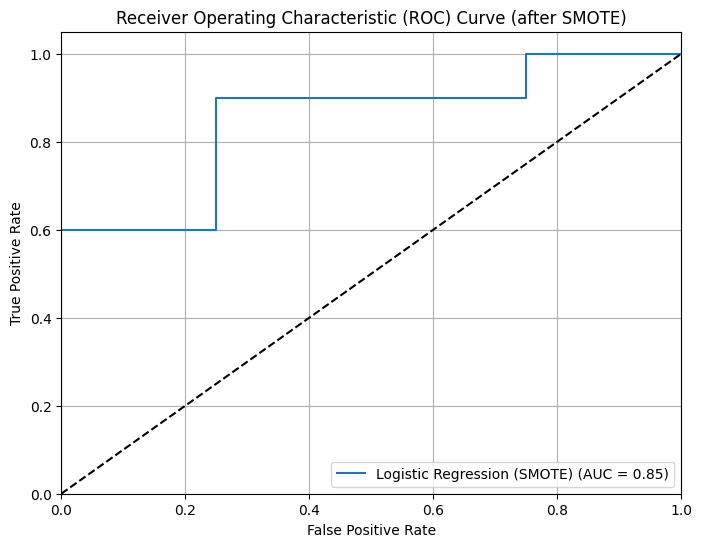

In [80]:
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X, y are already prepared from previous steps for the binary classification
# (X contains features, y is the binary target: 1 for well-being >= 8, 0 otherwise)

# First, let's check the class distribution in the original training data
# Assuming X_train and y_train are available from a previous train_test_split
# If not, split the data first:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
# Using stratify=y is important for imbalanced data to maintain the class proportion in splits.

print("Original training set shape:", X_train.shape, y_train.shape)
print("Original training set class distribution:\n", y_train.value_counts())

# Initialize SMOTE
# random_state for reproducibility
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nResampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)
print("Resampled training set class distribution:\n", y_train_resampled.value_counts())

# Now train your model (e.g., Logistic Regression) on the resampled data

# Initialize the Logistic Regression model
logistic_model_resampled = LogisticRegression(random_state=42, solver='liblinear')

# Train the model on the RESAMPLED training data
logistic_model_resampled.fit(X_train_resampled, y_train_resampled)

# Evaluate the model on the ORIGINAL test set (do NOT resample the test set)
logistic_y_pred_resampled = logistic_model_resampled.predict(X_test)
logistic_y_prob_resampled = logistic_model_resampled.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Results (after SMOTE):")
print("Accuracy:", accuracy_score(y_test, logistic_y_pred_resampled))
print("\nClassification Report:\n", classification_report(y_test, logistic_y_pred_resampled))
print("ROC AUC Score:", roc_auc_score(y_test, logistic_y_prob_resampled))

# Plot ROC Curve
fpr_resampled, tpr_resampled, thresholds_resampled = roc_curve(y_test, logistic_y_prob_resampled)
plt.figure(figsize=(8, 6))
plt.plot(fpr_resampled, tpr_resampled, label=f'Logistic Regression (SMOTE) (AUC = {roc_auc_score(y_test, logistic_y_prob_resampled):.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (after SMOTE)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

2. Undersampling the Majority Class
Undersampling removes samples from the majority class to match the number of samples in the minority class. This can lead to loss of information.

Original training set shape: (40, 231) (40,)
Original training set class distribution:
 Vispārējās_labsajūtas_rādītājs
1    25
0    15
Name: count, dtype: int64

Resampled (Undersampled) training set shape: (30, 231) (30,)
Resampled (Undersampled) training set class distribution:
 Vispārējās_labsajūtas_rādītājs
0    15
1    15
Name: count, dtype: int64

Logistic Regression Results (after Undersampling):
Accuracy: 0.7857142857142857

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.89      0.80      0.84        10

    accuracy                           0.79        14
   macro avg       0.74      0.78      0.75        14
weighted avg       0.81      0.79      0.79        14

ROC AUC Score: 0.9


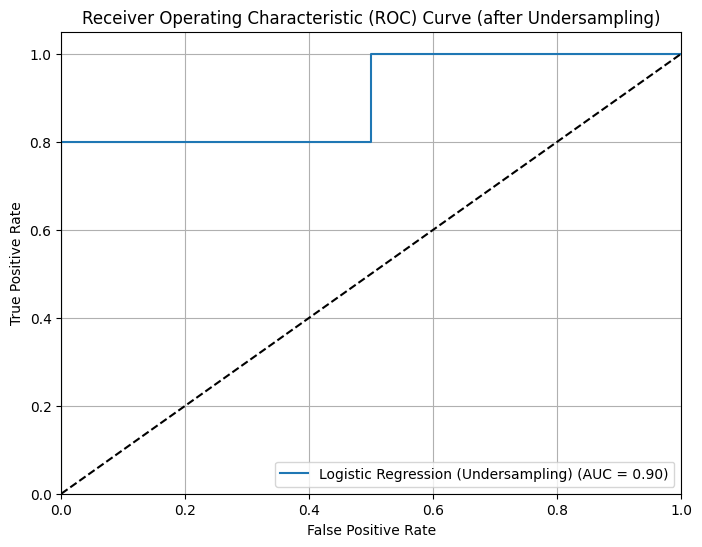

In [81]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X, y are already prepared from previous steps for the binary classification
# Assuming X_train and y_train are available from a previous train_test_split

print("Original training set shape:", X_train.shape, y_train.shape)
print("Original training set class distribution:\n", y_train.value_counts())

# Initialize RandomUnderSampler
# random_state for reproducibility
rus = RandomUnderSampler(random_state=42)

# Apply RandomUnderSampler to the training data
X_train_resampled_under, y_train_resampled_under = rus.fit_resample(X_train, y_train)

print("\nResampled (Undersampled) training set shape:", X_train_resampled_under.shape, y_train_resampled_under.shape)
print("Resampled (Undersampled) training set class distribution:\n", y_train_resampled_under.value_counts())

# Now train your model (e.g., Logistic Regression) on the undersampled data

# Initialize the Logistic Regression model
logistic_model_undersampled = LogisticRegression(random_state=42, solver='liblinear')

# Train the model on the RESAMPLED (undersampled) training data
logistic_model_undersampled.fit(X_train_resampled_under, y_train_resampled_under)

# Evaluate the model on the ORIGINAL test set
logistic_y_pred_undersampled = logistic_model_undersampled.predict(X_test)
logistic_y_prob_undersampled = logistic_model_undersampled.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Results (after Undersampling):")
print("Accuracy:", accuracy_score(y_test, logistic_y_pred_undersampled))
print("\nClassification Report:\n", classification_report(y_test, logistic_y_pred_undersampled))
print("ROC AUC Score:", roc_auc_score(y_test, logistic_y_prob_undersampled))

# Plot ROC Curve
fpr_undersampled, tpr_undersampled, thresholds_undersampled = roc_curve(y_test, logistic_y_prob_undersampled)
plt.figure(figsize=(8, 6))
plt.plot(fpr_undersampled, tpr_undersampled, label=f'Logistic Regression (Undersampling) (AUC = {roc_auc_score(y_test, logistic_y_prob_undersampled):.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (after Undersampling)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

This code block demonstrates undersampling the majority class using RandomUnderSampler. It randomly removes instances from the majority class until its size matches the minority class. This can be faster than oversampling but may discard valuable information. Similar to SMOTE, the model is trained on the resampled training data and evaluated on the original test set.

3. Class Weights
Many machine learning models allow you to specify class weights. This tells the model to pay more attention to samples from the minority class during training. This is a simple and often effective method that doesn't change the dataset size.

Original training set shape: (40, 231) (40,)
Original training set class distribution:
 Vispārējās_labsajūtas_rādītājs
1    25
0    15
Name: count, dtype: int64

Logistic Regression Results (with class_weight='balanced'):
Accuracy: 0.8571428571428571

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.90      0.90      0.90        10

    accuracy                           0.86        14
   macro avg       0.82      0.82      0.82        14
weighted avg       0.86      0.86      0.86        14

ROC AUC Score: 0.875


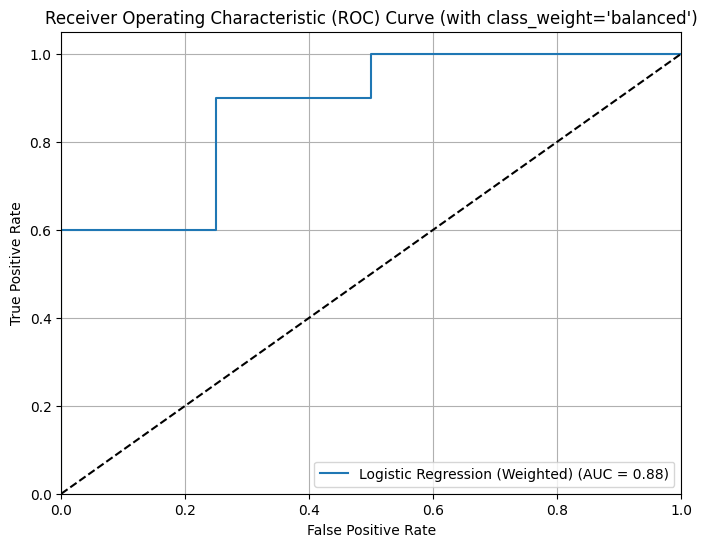

In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X, y are already prepared from previous steps for the binary classification
# Assuming X_train and y_train are available from a previous train_test_split

print("Original training set shape:", X_train.shape, y_train.shape)
print("Original training set class distribution:\n", y_train.value_counts())

# Initialize the Logistic Regression model with class_weight='balanced'
# 'balanced' automatically adjusts weights inversely proportional to class frequencies
logistic_model_weighted = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')

# Train the model on the ORIGINAL training data
# No resampling of the data is needed for this approach
logistic_model_weighted.fit(X_train, y_train)

# Evaluate the model on the ORIGINAL test set
logistic_y_pred_weighted = logistic_model_weighted.predict(X_test)
logistic_y_prob_weighted = logistic_model_weighted.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Results (with class_weight='balanced'):")
print("Accuracy:", accuracy_score(y_test, logistic_y_pred_weighted))
print("\nClassification Report:\n", classification_report(y_test, logistic_y_pred_weighted))
print("ROC AUC Score:", roc_auc_score(y_test, logistic_y_prob_weighted))

# Plot ROC Curve
fpr_weighted, tpr_weighted, thresholds_weighted = roc_curve(y_test, logistic_y_prob_weighted)
plt.figure(figsize=(8, 6))
plt.plot(fpr_weighted, tpr_weighted, label=f'Logistic Regression (Weighted) (AUC = {roc_auc_score(y_test, logistic_y_prob_weighted):.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (with class_weight=\'balanced\')')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

This code block shows how to use the class_weight='balanced' parameter in the LogisticRegression model. This automatically calculates and applies weights to the classes during the training process, giving more importance to the minority class. The model is trained on the original data, and evaluation is done on the original test set.

You can try these different techniques and compare the model performance using metrics like F1-score and ROC AUC to see which method works best for your specific dataset and classification problem. Random Forest models also have a class_weight parameter you can use.

##Results and Discussion

<ipython-input-66-bbd842f3574e>:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_department_counts = structured_data_with_clusters.groupby(['Nodaļa_Anonymized', 'Engagement_Cluster_Name']).size().unstack(fill_value=0)


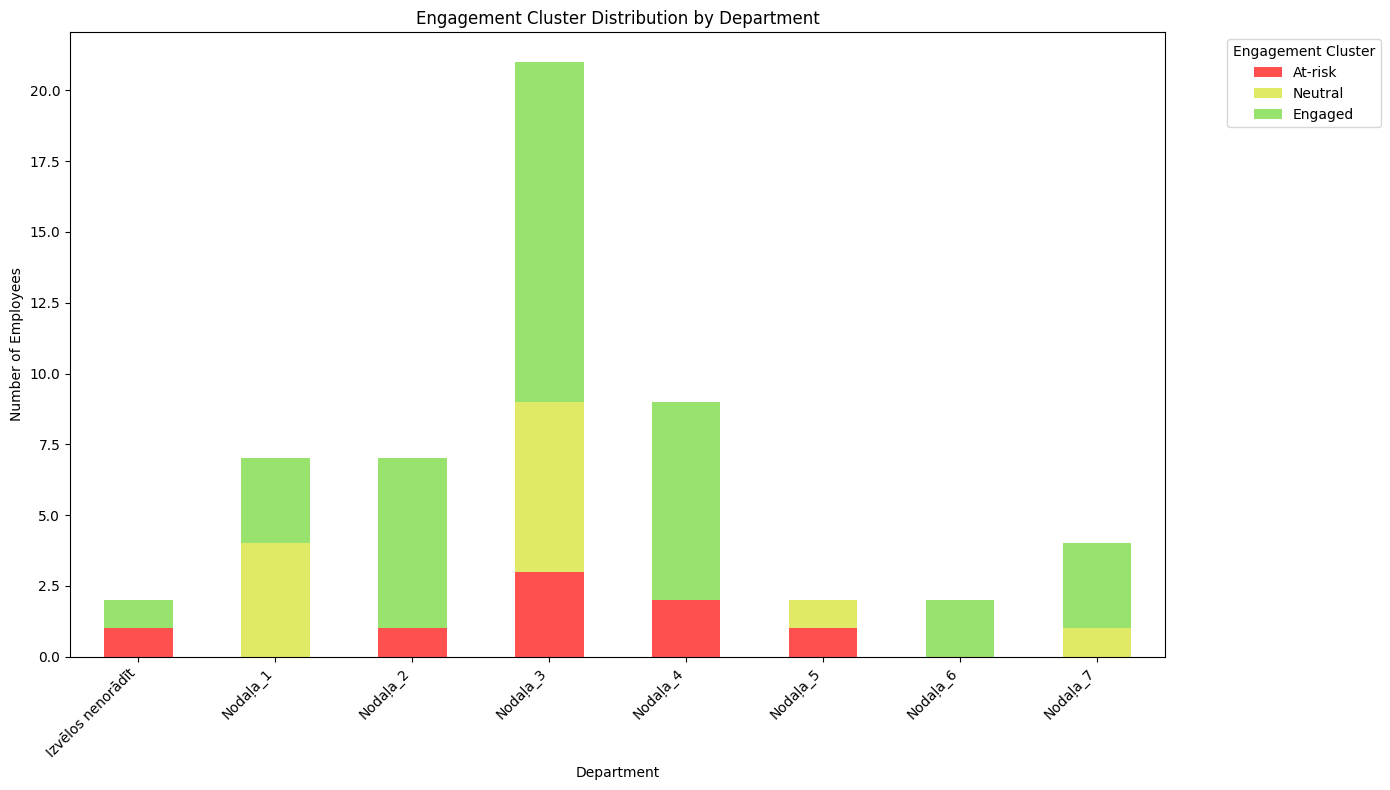

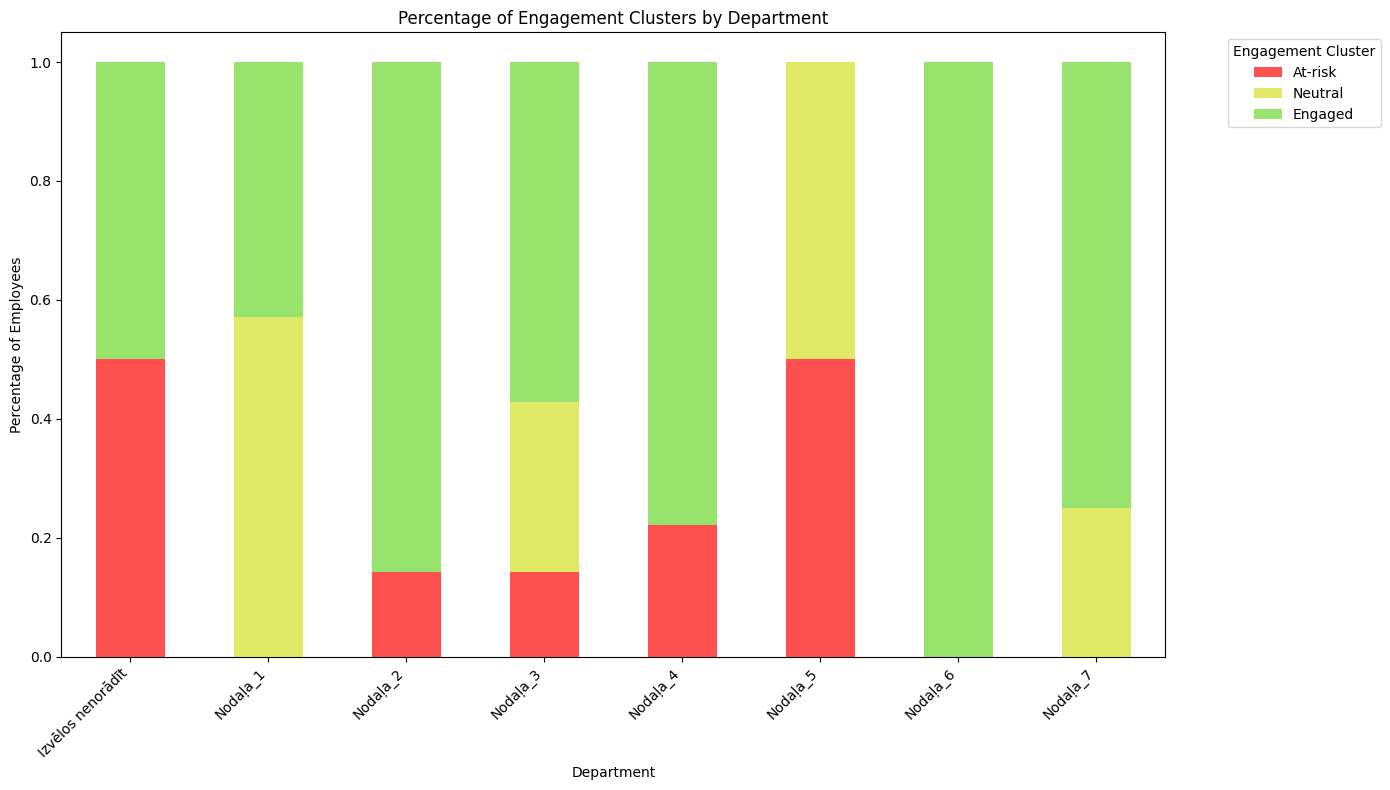

In [ ]:
# prompt: use data from Kmeans before and visualise by departments using same colors for clusters

import matplotlib.pyplot as plt
# Assuming 'structured_data_with_clusters' DataFrame with 'Engagement_Cluster_Name' is available
# and 'Department_Anonymized' is the column representing departments.
# And 'cluster_colors' dictionary mapping cluster names to colors is defined.

if 'Nodaļa_Anonymized' in structured_data_with_clusters.columns and 'Engagement_Cluster_Name' in structured_data_with_clusters.columns and cluster_colors:

    # Count the number of employees in each cluster within each department
    cluster_department_counts = structured_data_with_clusters.groupby(['Nodaļa_Anonymized', 'Engagement_Cluster_Name']).size().unstack(fill_value=0)

    # Optional: Reorder columns based on defined cluster order for consistent plotting
    ordered_clusters = ['At-risk', 'Neutral', 'Engaged']
    cluster_department_counts = cluster_department_counts[ordered_clusters]

    # Plotting the distribution of clusters within each department
    cluster_department_counts.plot(kind='bar', stacked=True, figsize=(14, 8), color=[cluster_colors.get(col, '#808080') for col in cluster_department_counts.columns]) # Use cluster_colors for bars
    plt.title('Engagement Cluster Distribution by Department')
    plt.xlabel('Department')
    plt.ylabel('Number of Employees')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Engagement Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Optional: Plotting the percentage distribution of clusters within each department
    # Calculate percentage within each department
    cluster_department_percentage = cluster_department_counts.apply(lambda x: x / x.sum(), axis=1)

    cluster_department_percentage.plot(kind='bar', stacked=True, figsize=(14, 8), color=[cluster_colors.get(col, '#808080') for col in cluster_department_percentage.columns]) # Use cluster_colors for bars
    plt.title('Percentage of Engagement Clusters by Department')
    plt.xlabel('Department')
    plt.ylabel('Percentage of Employees')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Engagement Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

else:
    print("Required columns ('Nodaļa_Anonymized' or 'Engagement_Cluster_Name') or 'cluster_colors' dictionary not found.")



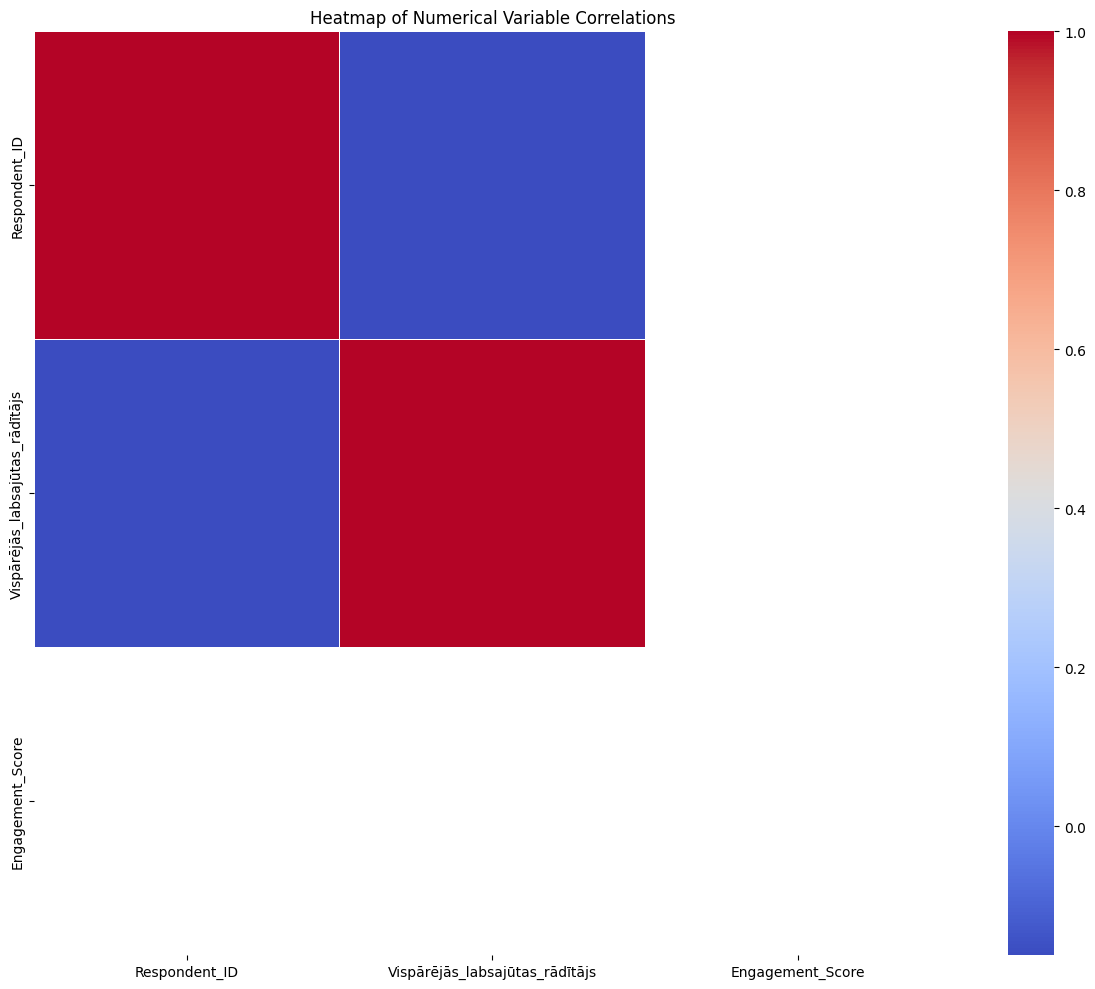

In [72]:
# prompt: create a heatmap to visualize numeric variables

import matplotlib.pyplot as plt
import numpy as np
# Select only numerical columns for the heatmap
numeric_cols = merged_data.select_dtypes(include=np.number)

# Drop columns with too many missing values if necessary (threshold can be adjusted)
numeric_cols = numeric_cols.dropna(axis=1, thresh=len(numeric_cols)*0.75) # Example: keep columns with >= 75% non-null values

# Drop columns with near-zero variance if necessary
# This might not be needed if features are already scaled and relevant
# from sklearn.feature_selection import VarianceThreshold
# selector = VarianceThreshold(threshold=0.01) # Adjust threshold
# selector.fit(numeric_cols)
# numeric_cols = numeric_cols[numeric_cols.columns[selector.get_support()]]


# Calculate the correlation matrix
correlation_matrix = numeric_cols.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap of Numerical Variable Correlations')
plt.tight_layout()
plt.show()

In [ ]:
# prompt: how to load data with new features included? Is it possible to export?

import pandas as pd
# To load the data with new features included, you would read the saved files:
loaded_X = pd.read_parquet('processed_features_X.parquet')
loaded_y = pd.read_csv('processed_target_y.csv')

# If you saved the merged data:
# loaded_merged_data = pd.read_parquet('processed_merged_data.parquet')

print("\nData loaded from files:")
print("Loaded X shape:", loaded_X.shape)
print("Loaded y shape:", loaded_y.shape)
# print("Loaded merged data shape (if saved):", loaded_merged_data.shape if 'loaded_merged_data' in locals() else "Not saved")

# Now 'loaded_X' is a DataFrame containing all your engineered features (scaled numerical, one-hot encoded categorical, sentiment scores)
# and 'loaded_y' is the target variable (binary or continuous, depending on which one you saved).

# You can now use 'loaded_X' and 'loaded_y' directly for model training, testing, or further analysis
# without re-running the preprocessing steps.

# Example: Re-split the loaded data for training and testing
X_train_loaded, X_test_loaded, y_train_loaded, y_test_loaded = train_test_split(loaded_X, loaded_y, test_size=0.25, random_state=42)

print("\nLoaded data split into training and testing sets:")
print("Shape of X_train_loaded:", X_train_loaded.shape)
print("Shape of X_test_loaded:", X_test_loaded.shape)
print("Shape of y_train_loaded:", y_train_loaded.shape)
print("Shape of y_test_loaded:", y_test_loaded.shape)

# You can then train a model using this loaded data:
# model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(X_train_loaded, y_train_loaded)
# ... (evaluate the model)


# To export data after adding features, you can use pandas' to_csv, to_excel, to_json, to_parquet methods.
# You have already saved X and y to .parquet and .csv respectively in the previous code snippet.

# Example: Save the DataFrame that includes cluster assignments
# Make sure 'structured_data_with_clusters' is the DataFrame you want to export,
# containing original columns, new features, and cluster labels.
# If 'structured_data_with_clusters' exists from the clustering step:
if 'structured_data_with_clusters' in locals():
    output_filename_csv = 'employee_data_with_features_and_clusters.csv'
    output_filename_parquet = 'employee_data_with_features_and_clusters.parquet'

    # Export to CSV
    structured_data_with_clusters.to_csv(output_filename_csv, index=False)
    print(f"\nData with features and clusters saved to '{output_filename_csv}' (CSV)")

    # Export to Parquet (generally more efficient for larger datasets)
    structured_data_with_clusters.to_parquet(output_filename_parquet)
    print(f"Data with features and clusters saved to '{output_filename_parquet}' (Parquet)")

    # To download these files from Colab:
    # from google.colab import files
    # files.download(output_filename_csv)
    # files.download(output_filename_parquet)

else:
    print("\n'structured_data_with_clusters' DataFrame not found. Rerun the clustering steps if needed.")




Data loaded from files:
Loaded X shape: (54, 247)
Loaded y shape: (54, 1)

Loaded data split into training and testing sets:
Shape of X_train_loaded: (40, 247)
Shape of X_test_loaded: (14, 247)
Shape of y_train_loaded: (40, 1)
Shape of y_test_loaded: (14, 1)

Data with features and clusters saved to 'employee_data_with_features_and_clusters.csv' (CSV)
Data with features and clusters saved to 'employee_data_with_features_and_clusters.parquet' (Parquet)


See Project report added to this Google Colab Notebook.

##Conclusion

*   Ontology Framework - The developed ontology provided a structured representation of employee wellbeing data, enhancing data organization and integration. This framework improves semantic analysis, scalability, and AI system compatibility.
*   Privacy and Trust Measures - Privacy-preserving techniques like anonymization, encryption, and federated learning ensured secure and ethical data handling. These measures-built trust among stakeholders and complied with regulatory standards like GDPR.
* Machine Learning Success - Predictive models effectively identified patterns in employee well-being, demonstrating AI's potential in HR analytics. However, integrating Explainable AI (XAI) could improve model interpretability and stakeholder trust.
* Scalability and Real-World Application - AI solutions for employee wellbeing can revolutionize HR by providing actionable insights. Future work should focus on leveraging cloud technologies and advanced privacy methods to enhance scalability and adoption.


##References

1. Amazon Web Services, Inc., n.d. Define Lambda function handler in Python [WWW Document]. AWS. URL https://docs.aws.amazon.com/lambda/latest/dg/python-handler.html#python-best-practices (accessed 12.2.24).
2.	Cloud Storage Tutorial [WWW Document], n.d. . Google Cloud. URL https://cloud.google.com/functions/docs/tutorials/storage#functions-prepare-environment-python (accessed 12.2.24).
3.	Data and Beyond, n.d. . A blog on Data Science & Machine Learning for beginner. URL dataandbeyond.wordpress.com/2017/08/24/grid-search/ (accessed 12.2.24).
4.	Gabriel Suarez, 2023. ArticleAISupervisedLearning [WWW Document]. github. URL https://github.com/GabrielSB19/ArticleAISupervisedLearning (accessed 12.2.24).
5.	George, N., 2021. Practical Data Science with Python: Learn tools and techniques from hands-on examples to extract insights from data, 1st ed. Packt Publishing, Birmingham.
6.	Kelleher, J.D., Mac Namee, B., D’Arcy, A., 2020. Fundamentals of machine learning for predictive data analytics : algorithms, worked examples, and case studies., Second edition. ed. The MIT Press, Cambridge, Massachusetts.
7.	Ovh, 2020. Interpretability-engine [WWW Document]. github. URL https://github.com/ovh/interpretability-engine?tab=readme-ov-file (accessed 12.2.24).

